In [ ]:
"""
=============================================================================
SECTION 1: ENVIRONMENT SETUP
=============================================================================
Import all required libraries and set configurations
"""
!conda env create -f medical_imaging.yaml
!conda activate medical_imaging
!conda update -n base -c defaults conda
!conda init
!conda activate medical_imaging
!conda remove winpty --force
!conda install winpty


Jupyter detected...
3 channel Terms of Service accepted
Retrieving notices: done



EnvironmentFileNotFound: 'C:\Users\laofi\skin-lesion-classifier-HAM10000\medical_imaging.yaml' file not found



^C
Jupyter detected...
3 channel Terms of Service accepted
Channels:
 - defaults
Platform: win-64
no change     C:\Users\laofi\anaconda3\Scripts\conda.exe
no change     C:\Users\laofi\anaconda3\Scripts\conda-env.exe
no change     C:\Users\laofi\anaconda3\Scripts\conda-script.py
no change     C:\Users\laofi\anaconda3\Scripts\conda-env-script.py
no change     C:\Users\laofi\anaconda3\condabin\conda.bat
no change     C:\Users\laofi\anaconda3\Library\bin\conda.bat
no change     C:\Users\laofi\anaconda3\condabin\_conda_activate.bat
no change     C:\Users\laofi\anaconda3\condabin\rename_tmp.bat
no change     C:\Users\laofi\anaconda3\condabin\conda_auto_activate.bat
no change     C:\Users\laofi\anaconda3\condabin\conda_hook.bat
no change     C:\Users\laofi\anaconda3\Scripts\activate.bat
no change     C:\Users\laofi\anaconda3\condabin\activate.bat
no change     C:\Users\laofi\anaconda3\condabin\deactivate.bat
no change     C:\Users\laofi\anaconda3\Scripts\activate
no change     C:\Users\laofi\

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import cv2
import pickle
import json
import time
from pathlib import Path
from scipy.ndimage import gaussian_filter, map_coordinates

# Sklearn imports
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report,
    roc_curve, auc, roc_auc_score
)

# Visualization settings
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Device configuration
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version: {torch.version.cuda}")

# Set random seeds for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

# Global configurations
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 7
NUM_EPOCHS = 20  # Full training

print("\n" + "="*80)
print("ENVIRONMENT SETUP COMPLETE")
print("="*80)

Using device: cuda
GPU: NVIDIA GeForce RTX 4070 Ti SUPER
CUDA Version: 12.1

ENVIRONMENT SETUP COMPLETE


In [2]:
"""
=============================================================================
SECTION 2: DATA LOADING AND EXPLORATION
=============================================================================
Load HAM10000 dataset from two parts and perform exploratory data analysis
"""

# Define data paths - IMAGES ARE IN TWO FOLDERS
DATA_DIR_PART1 = Path('data/raw/HAM10000_images_part_1')
DATA_DIR_PART2 = Path('data/raw/HAM10000_images_part_2')
METADATA_FILE = 'data/raw/HAM10000_metadata.csv'

# Verify directories exist
print("Checking image directories...")
if DATA_DIR_PART1.exists():
    img_count_1 = len(list(DATA_DIR_PART1.glob('*.jpg')))
    print(f"✓ Part 1: {img_count_1} images in {DATA_DIR_PART1}")
else:
    print(f"✗ Part 1 not found: {DATA_DIR_PART1}")
    img_count_1 = 0

if DATA_DIR_PART2.exists():
    img_count_2 = len(list(DATA_DIR_PART2.glob('*.jpg')))
    print(f"✓ Part 2: {img_count_2} images in {DATA_DIR_PART2}")
else:
    print(f"✗ Part 2 not found: {DATA_DIR_PART2}")
    img_count_2 = 0

print(f"\nTotal images: {img_count_1 + img_count_2}")

# Load metadata
print(f"\nLoading metadata from: {METADATA_FILE}")
metadata = pd.read_csv(METADATA_FILE)

print(f"Dataset loaded: {len(metadata)} samples")
print(f"\nColumns: {metadata.columns.tolist()}")
print(f"\nFirst few rows:")
metadata.head()

Checking image directories...
✓ Part 1: 5000 images in data\raw\HAM10000_images_part_1
✓ Part 2: 5015 images in data\raw\HAM10000_images_part_2

Total images: 10015

Loading metadata from: data/raw/HAM10000_metadata.csv
Dataset loaded: 10015 samples

Columns: ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization']

First few rows:


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


Class Distribution:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

Imbalance Ratio: 58.3:1


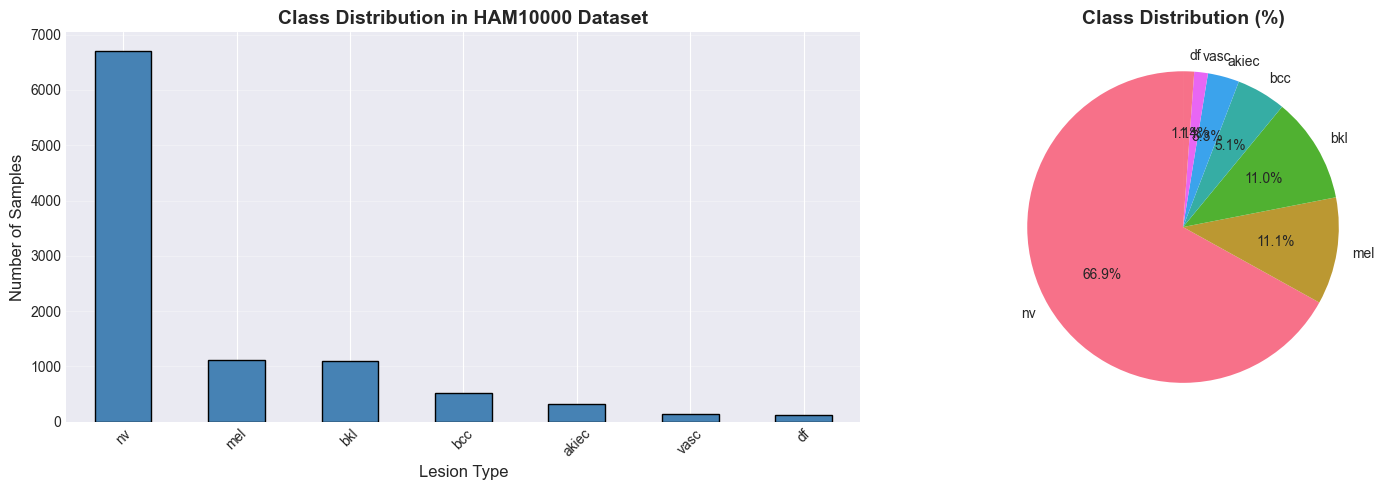


KEY OBSERVATIONS:
• Most common class: nv (Melanocytic nevi) - 6705 samples (66.8%)
• Rarest class: df (Dermatofibroma) - 115 samples (1.1%)
• Severe imbalance: 58.3:1 ratio
• Cancer classes: mel (1113), bcc (514)


In [3]:
"""
2.1 CLASS DISTRIBUTION ANALYSIS
Visualize class imbalance
"""

# Class counts
class_counts = metadata['dx'].value_counts()
print("Class Distribution:")
print(class_counts)
print(f"\nImbalance Ratio: {class_counts.max() / class_counts.min():.1f}:1")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar plot
class_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Class Distribution in HAM10000 Dataset', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Lesion Type', fontsize=12)
axes[0].set_ylabel('Number of Samples', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# Pie chart
class_counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Class Distribution (%)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

# Class name mapping
CLASS_NAMES = {
    'akiec': 'Actinic keratoses',
    'bcc': 'Basal cell carcinoma',
    'bkl': 'Benign keratosis',
    'df': 'Dermatofibroma',
    'mel': 'Melanoma',
    'nv': 'Melanocytic nevi',
    'vasc': 'Vascular lesions'
}

print("\n" + "="*80)
print("KEY OBSERVATIONS:")
print("="*80)
print(f"• Most common class: nv (Melanocytic nevi) - {class_counts['nv']} samples (66.8%)")
print(f"• Rarest class: df (Dermatofibroma) - {class_counts['df']} samples (1.1%)")
print(f"• Severe imbalance: {class_counts['nv']/class_counts['df']:.1f}:1 ratio")
print(f"• Cancer classes: mel ({class_counts['mel']}), bcc ({class_counts['bcc']})")


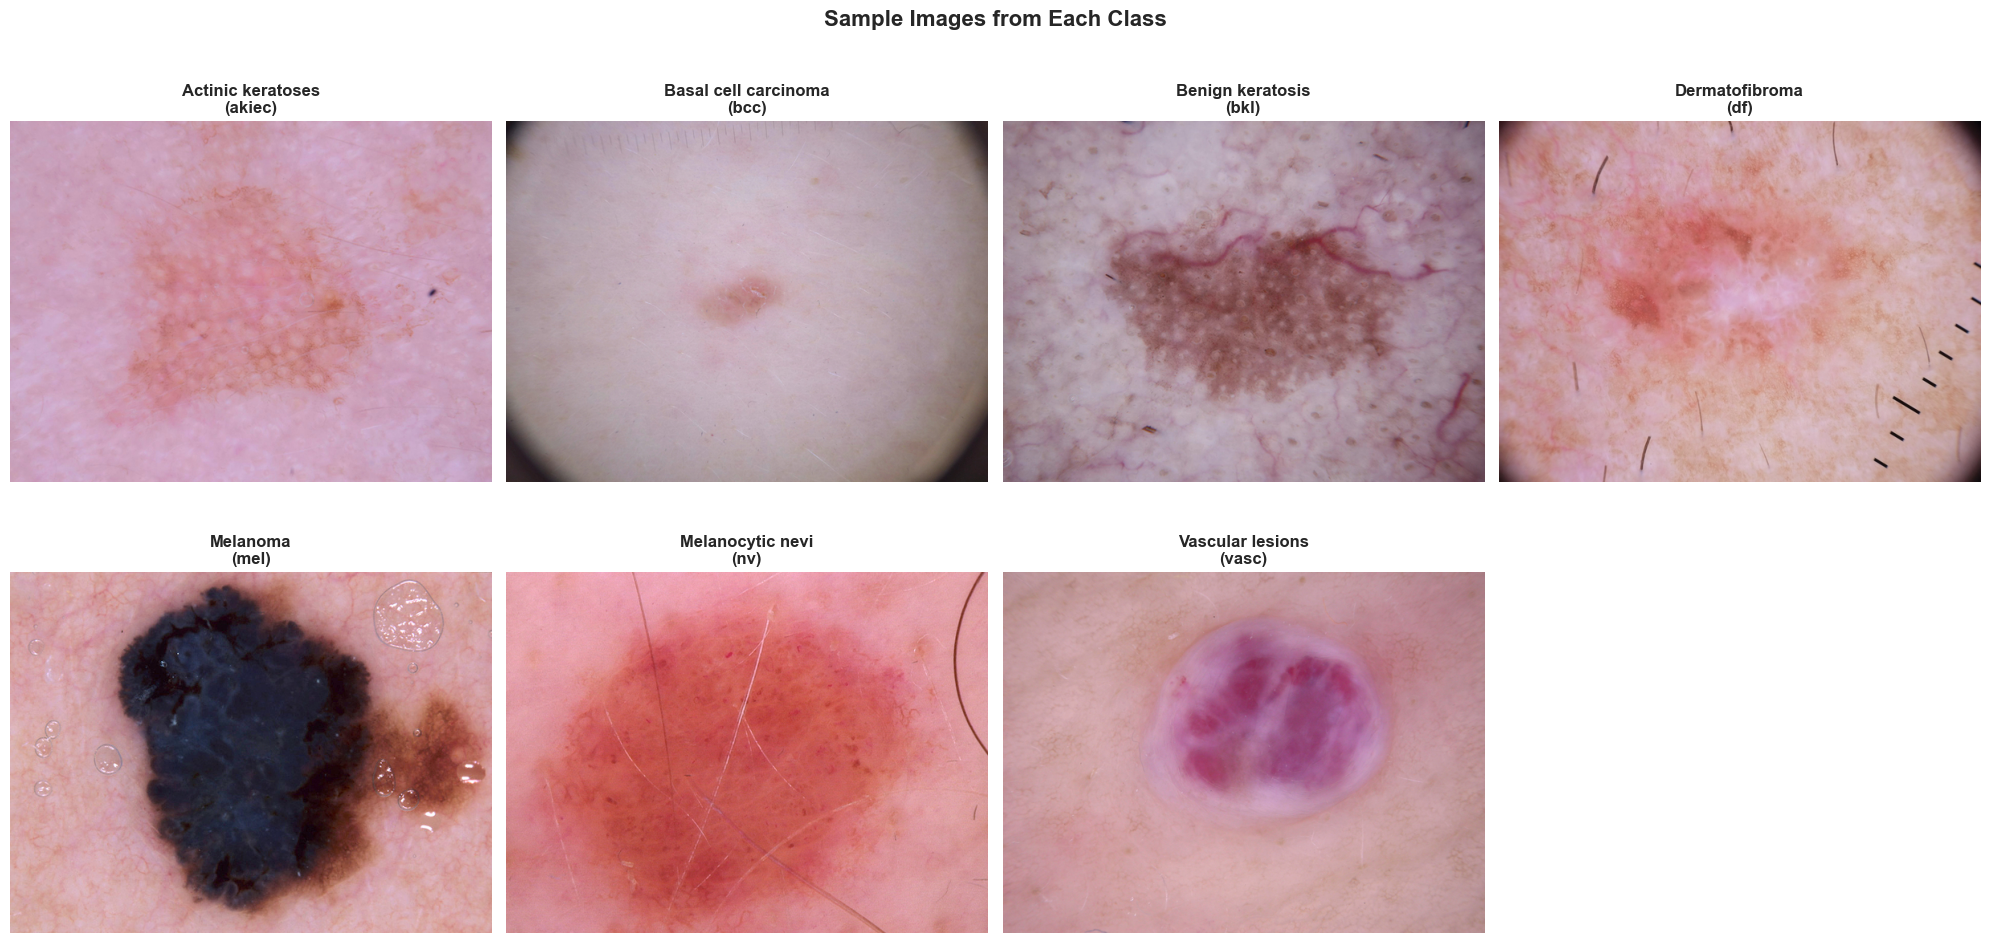

Sample images displayed for all 7 classes


In [4]:
"""
2.2 SAMPLE IMAGES FROM EACH CLASS
Visualize representative images
"""

# Define paths (in case Cell 3 wasn't run)
from pathlib import Path
DATA_DIR_PART1 = Path('data/raw/HAM10000_images_part_1')
DATA_DIR_PART2 = Path('data/raw/HAM10000_images_part_2')

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, (class_code, class_name) in enumerate(CLASS_NAMES.items()):
    # Get random sample from this class
    sample = metadata[metadata['dx'] == class_code].sample(1).iloc[0]
    image_id = sample['image_id']
    
    # Check both folders for the image
    path1 = DATA_DIR_PART1 / f"{image_id}.jpg"
    path2 = DATA_DIR_PART2 / f"{image_id}.jpg"
    
    if path1.exists():
        img_path = path1
    elif path2.exists():
        img_path = path2
    else:
        print(f"Warning: Image {image_id} not found in either folder")
        continue
    
    # Load and display image
    img = Image.open(img_path)
    axes[idx].imshow(img)
    axes[idx].set_title(f"{class_name}\n({class_code})", fontsize=12, fontweight='bold')
    axes[idx].axis('off')

# Remove empty subplot
fig.delaxes(axes[-1])

plt.suptitle('Sample Images from Each Class', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("Sample images displayed for all 7 classes")

In [5]:
"""
=============================================================================
SECTION 3: DATA PREPROCESSING
=============================================================================
Prepare data for training: encoding, splitting, and path creation
"""
import os
# Add full image paths - CHECK BOTH DIRECTORIES
def get_image_path(image_id):
    """Find image in either part_1 or part_2 folder"""
    path1 = DATA_DIR_PART1 / f"{image_id}.jpg"
    path2 = DATA_DIR_PART2 / f"{image_id}.jpg"
    
    if path1.exists():
        return str(path1)
    elif path2.exists():
        return str(path2)
    else:
        # Return path1 anyway (will be caught later if missing)
        return str(path1)

print("Creating image paths...")
metadata['image_path'] = metadata['image_id'].apply(get_image_path)

# Verify paths exist
existing_paths = metadata['image_path'].apply(lambda x: os.path.exists(x))
print(f"\n✓ Valid paths: {existing_paths.sum()} / {len(metadata)}")
if existing_paths.sum() < len(metadata):
    missing = len(metadata) - existing_paths.sum()
    print(f"⚠️ Warning: {missing} images not found")
else:
    print("✓ All images found!")

# Encode labels
le = LabelEncoder()
metadata['label'] = le.fit_transform(metadata['dx'])

print("\nLabel Encoding:")
for idx, class_name in enumerate(le.classes_):
    print(f"  {idx}: {class_name} ({CLASS_NAMES[class_name]})")

# Save label encoder
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)
print("\nLabel encoder saved to 'label_encoder.pkl'")

# Stratified train-val-test split
print("\n" + "="*80)
print("DATA SPLITTING (Stratified)")
print("="*80)

# First split: train+val (85%) and test (15%)
train_val_df, test_df = train_test_split(
    metadata,
    test_size=0.15,
    stratify=metadata['dx'],
    random_state=SEED
)

# Second split: train (82.35% of train+val ≈ 70% total) and val (17.65% ≈ 15% total)
train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.1765,
    stratify=train_val_df['dx'],
    random_state=SEED
)

print(f"Training set:   {len(train_df):,} samples ({len(train_df)/len(metadata)*100:.1f}%)")
print(f"Validation set: {len(val_df):,} samples ({len(val_df)/len(metadata)*100:.1f}%)")
print(f"Test set:       {len(test_df):,} samples ({len(test_df)/len(metadata)*100:.1f}%)")
print(f"Total:          {len(metadata):,} samples")

# Save splits
train_df.to_csv('train_data.csv', index=False)
val_df.to_csv('val_data.csv', index=False)
test_df.to_csv('test_data.csv', index=False)
print("\nData splits saved to CSV files")

# Verify stratification
print("\n" + "="*80)
print("VERIFYING STRATIFICATION")
print("="*80)

splits = {'Train': train_df, 'Validation': val_df, 'Test': test_df}
for split_name, split_df in splits.items():
    print(f"\n{split_name} Set Distribution:")
    dist = split_df['dx'].value_counts(normalize=True).sort_index()
    for class_code, percentage in dist.items():
        print(f"  {class_code}: {percentage*100:.1f}%")

Creating image paths...

✓ Valid paths: 10015 / 10015
✓ All images found!

Label Encoding:
  0: akiec (Actinic keratoses)
  1: bcc (Basal cell carcinoma)
  2: bkl (Benign keratosis)
  3: df (Dermatofibroma)
  4: mel (Melanoma)
  5: nv (Melanocytic nevi)
  6: vasc (Vascular lesions)

Label encoder saved to 'label_encoder.pkl'

DATA SPLITTING (Stratified)
Training set:   7,009 samples (70.0%)
Validation set: 1,503 samples (15.0%)
Test set:       1,503 samples (15.0%)
Total:          10,015 samples

Data splits saved to CSV files

VERIFYING STRATIFICATION

Train Set Distribution:
  akiec: 3.3%
  bcc: 5.1%
  bkl: 11.0%
  df: 1.1%
  mel: 11.1%
  nv: 67.0%
  vasc: 1.4%

Validation Set Distribution:
  akiec: 3.3%
  bcc: 5.1%
  bkl: 11.0%
  df: 1.2%
  mel: 11.1%
  nv: 66.9%
  vasc: 1.4%

Test Set Distribution:
  akiec: 3.3%
  bcc: 5.1%
  bkl: 11.0%
  df: 1.1%
  mel: 11.1%
  nv: 66.9%
  vasc: 1.5%


4.1 CLASS WEIGHT CALCULATION

Training set class distribution:
  0 (akiec): 229 samples (3.3%)
  1 (bcc): 360 samples (5.1%)
  2 (bkl): 769 samples (11.0%)
  3 (df): 80 samples (1.1%)
  4 (mel): 779 samples (11.1%)
  5 (nv): 4,693 samples (67.0%)
  6 (vasc): 99 samples (1.4%)

--------------------------------------------------------------------------------
Computing Class Weights (3 Methods):
--------------------------------------------------------------------------------

1. Inverse Frequency Weights:
   [ 4.3724267   2.78134921  1.30206205 12.51607143  1.28534752  0.21335728
 10.11399711]

2. Sklearn Balanced Weights:
   [ 4.3724267   2.78134921  1.30206205 12.51607143  1.28534752  0.21335728
 10.11399711]

3. Effective Number Weights (SELECTED):
   [0.93982798 0.60174454 0.28746603 2.67033989 0.28391593 0.05680723
 2.15989839]


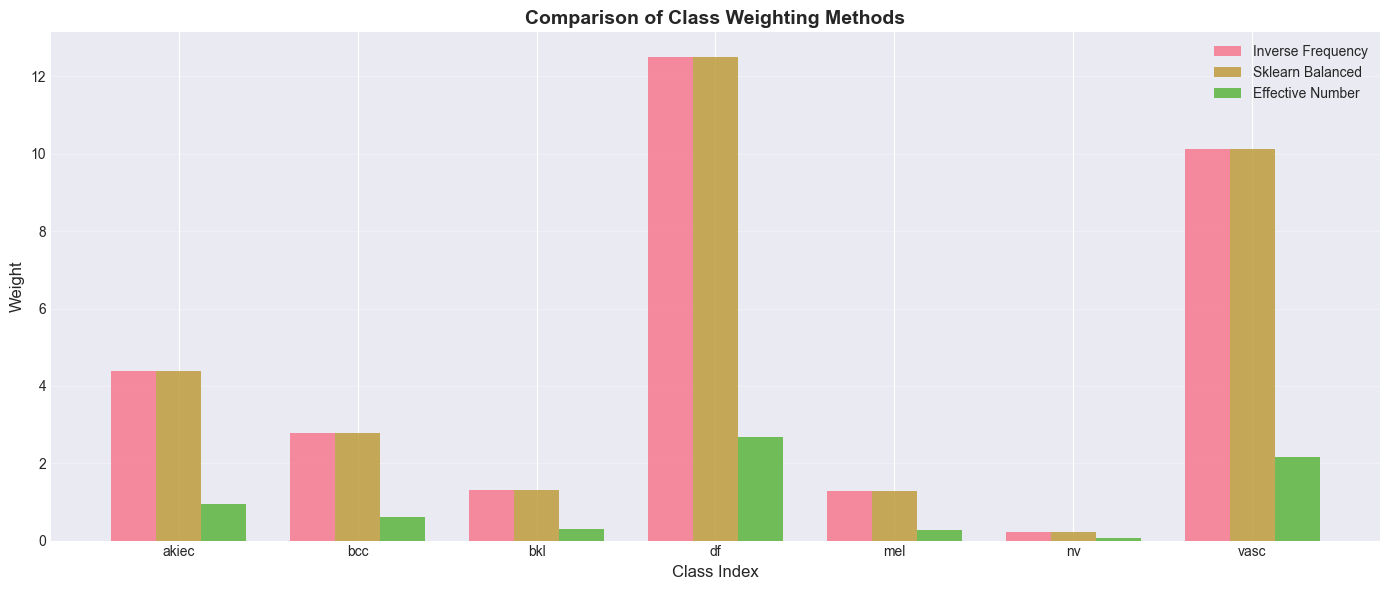


✓ Class weights saved to 'class_weights.pt'
✓ Selected method: Effective Number (beta=0.9999)


In [6]:
"""
=============================================================================
SECTION 4: CLASS IMBALANCE HANDLING
=============================================================================
Implement multiple strategies to handle severe class imbalance
"""

print("="*80)
print("4.1 CLASS WEIGHT CALCULATION")
print("="*80)

# Get class counts
train_labels = train_df['label'].values
class_counts = np.bincount(train_labels)
n_samples = len(train_labels)
n_classes = len(class_counts)

print(f"\nTraining set class distribution:")
for i, count in enumerate(class_counts):
    class_code = le.inverse_transform([i])[0]
    print(f"  {i} ({class_code}): {count:,} samples ({count/n_samples*100:.1f}%)")

# Calculate three types of class weights
print("\n" + "-"*80)
print("Computing Class Weights (3 Methods):")
print("-"*80)

# Method 1: Inverse Frequency
class_weights_inv = n_samples / (n_classes * class_counts)
print("\n1. Inverse Frequency Weights:")
print(f"   {class_weights_inv}")

# Method 2: Sklearn Balanced
class_weights_sklearn = compute_class_weight(
    'balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
print("\n2. Sklearn Balanced Weights:")
print(f"   {class_weights_sklearn}")

# Method 3: Effective Number of Samples (CHOSEN)
# Based on: "Class-Balanced Loss Based on Effective Number of Samples" (Cui et al., 2019)
beta = 0.9999
effective_num = 1.0 - np.power(beta, class_counts)
class_weights_effective = (1.0 - beta) / effective_num
class_weights_effective = class_weights_effective / class_weights_effective.sum() * n_classes

print("\n3. Effective Number Weights (SELECTED):")
print(f"   {class_weights_effective}")

# Visualization
fig, ax = plt.subplots(1, 1, figsize=(14, 6))
x = np.arange(n_classes)
width = 0.25

ax.bar(x - width, class_weights_inv, width, label='Inverse Frequency', alpha=0.8)
ax.bar(x, class_weights_sklearn, width, label='Sklearn Balanced', alpha=0.8)
ax.bar(x + width, class_weights_effective, width, label='Effective Number', alpha=0.8)

ax.set_xlabel('Class Index', fontsize=12)
ax.set_ylabel('Weight', fontsize=12)
ax.set_title('Comparison of Class Weighting Methods', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([le.inverse_transform([i])[0] for i in range(n_classes)])
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Convert to tensor and save
class_weights_effective_tensor = torch.FloatTensor(class_weights_effective).to(DEVICE)

torch.save({
    'inverse': torch.FloatTensor(class_weights_inv),
    'sklearn': torch.FloatTensor(class_weights_sklearn),
    'effective': torch.FloatTensor(class_weights_effective)
}, 'class_weights.pt')

print("\n✓ Class weights saved to 'class_weights.pt'")
print(f"✓ Selected method: Effective Number (beta={beta})")

4.2 WEIGHTED RANDOM SAMPLING

✓ Sample weights calculated: 7,009 samples
  Weight range: 0.0568 to 2.6703
  Weighting method: Effective Number of Samples (beta=0.9999)

Weight per class:
  Actinic keratoses              (akiec): 0.9398
  Basal cell carcinoma           (bcc): 0.6017
  Benign keratosis               (bkl): 0.2875
  Dermatofibroma                 (df): 2.6703
  Melanoma                       (mel): 0.2839
  Melanocytic nevi               (nv): 0.0568
  Vascular lesions               (vasc): 2.1599

✓ Sample weights saved to 'sample_weights.pt'

SAMPLING VERIFICATION (100 batches)

Sampled 3,200 images across 100 batches
Expected per class: 457 samples (14.3%)

Class distribution after sampling:
  Actinic keratoses             :  462 ( 14.4%) | Ideal: 14.3% | Deviation: +0.2% Excellent
  Basal cell carcinoma          :  419 ( 13.1%) | Ideal: 14.3% | Deviation: -1.2% Excellent
  Benign keratosis              :  467 ( 14.6%) | Ideal: 14.3% | Deviation: +0.3% Excellent
  Derm

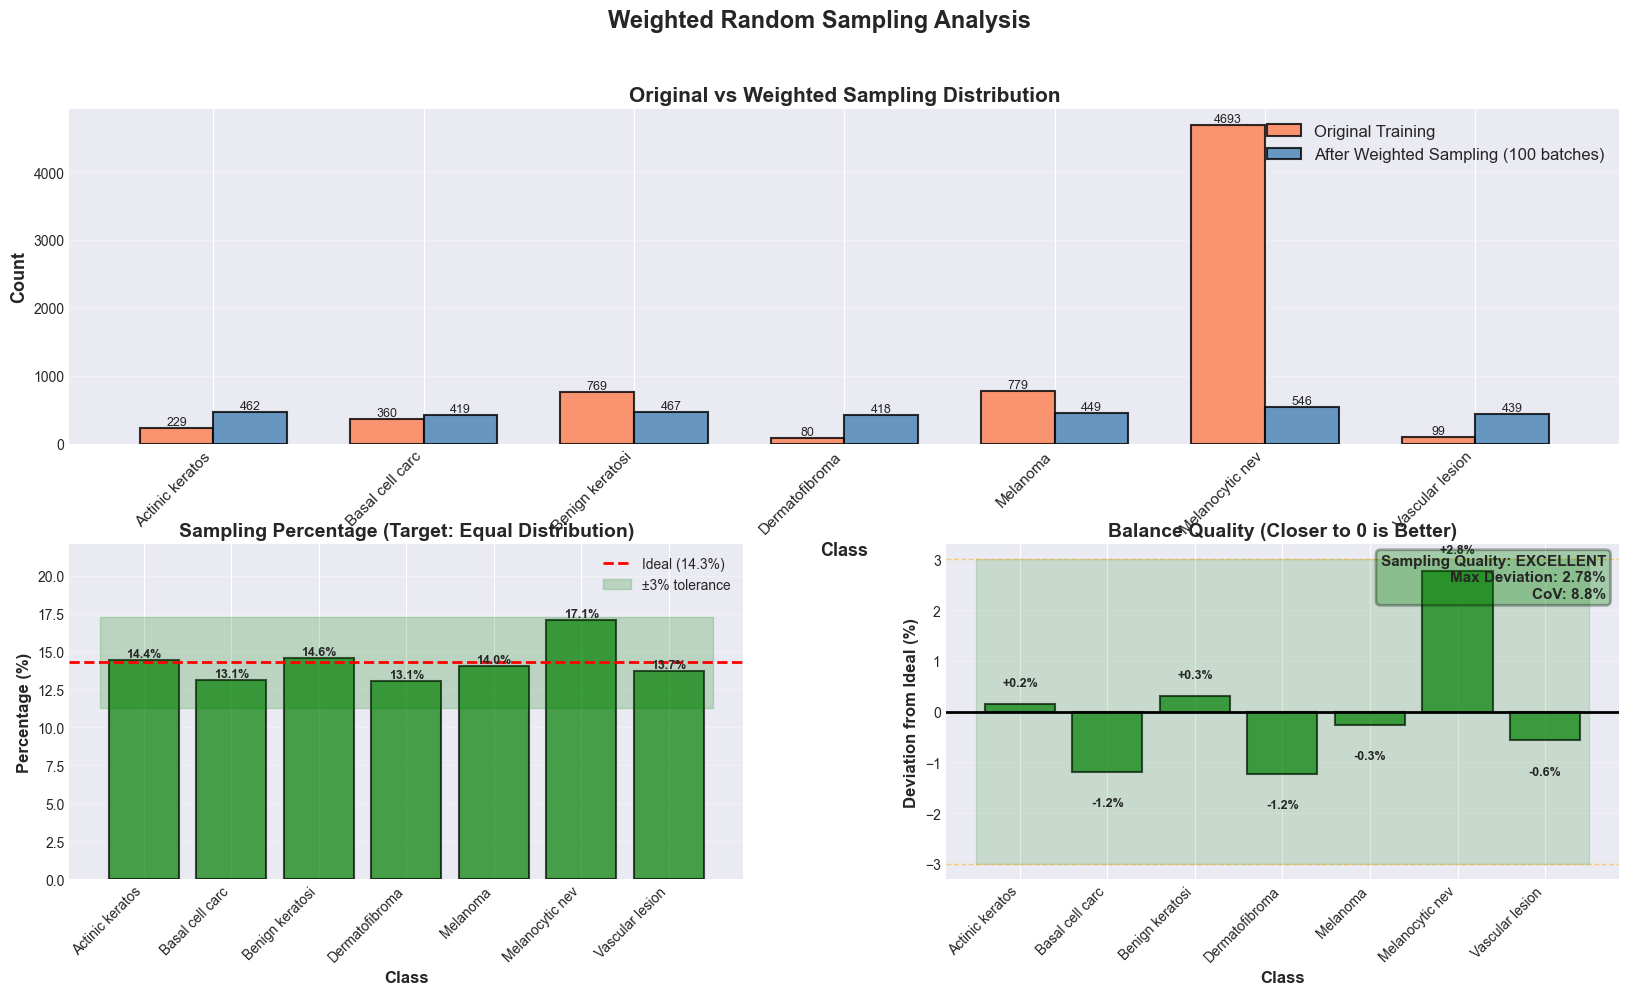


✓ Weighted sampling balances class distribution per batch
✓ Visualization saved: 'weighted_sampling_analysis.png'
✓ Verification data saved: 'sampling_verification.csv'

WEIGHTED SAMPLING SETUP COMPLETE


In [7]:
"""
4.2 WEIGHTED RANDOM SAMPLING
Create sample weights for balanced batch sampling with comprehensive verification
"""

print("="*80)
print("4.2 WEIGHTED RANDOM SAMPLING")
print("="*80)

# Calculate per-sample weights using effective number weights
sample_weights = np.array([class_weights_effective[label] for label in train_labels])

print(f"\n✓ Sample weights calculated: {len(sample_weights):,} samples")
print(f"  Weight range: {sample_weights.min():.4f} to {sample_weights.max():.4f}")
print(f"  Weighting method: Effective Number of Samples (beta=0.9999)")

# Show weight distribution
print("\nWeight per class:")
for idx in range(n_classes):
    class_code = le.inverse_transform([idx])[0]
    class_mask = train_labels == idx
    avg_weight = sample_weights[class_mask].mean()
    print(f"  {CLASS_NAMES[class_code]:30s} ({class_code}): {avg_weight:.4f}")

# Save for later use
torch.save(sample_weights, 'sample_weights.pt')
print("\n✓ Sample weights saved to 'sample_weights.pt'")

# ⭐ IMPROVED VERIFICATION: Sample 100 batches instead of 10
print("\n" + "="*80)
print("SAMPLING VERIFICATION (100 batches)")
print("="*80)

weighted_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=BATCH_SIZE * 100,  # 100 batches for better statistics
    replacement=True
)

sampled_labels = []
for idx in list(weighted_sampler):
    sampled_labels.append(train_labels[idx])

sampled_labels = np.array(sampled_labels)
sampled_counts = np.bincount(sampled_labels, minlength=n_classes)
total_sampled = len(sampled_labels)

# Calculate statistics
ideal_count = total_sampled / n_classes
ideal_percentage = 100 / n_classes

print(f"\nSampled {total_sampled:,} images across 100 batches")
print(f"Expected per class: {ideal_count:.0f} samples ({ideal_percentage:.1f}%)")
print(f"\nClass distribution after sampling:")

verification_data = []
for idx in range(n_classes):
    class_code = le.inverse_transform([idx])[0]
    count = sampled_counts[idx]
    percentage = count / total_sampled * 100
    deviation = percentage - ideal_percentage
    
    # Status indicator
    if abs(deviation) < 2:
        status = "Excellent"
    elif abs(deviation) < 4:
        status = "Good"
    elif abs(deviation) < 6:
        status = "Moderate with Risk"
    else:
        status = "Bad"
    
    verification_data.append({
        'Class': CLASS_NAMES[class_code][:25],
        'Original': class_counts[idx],
        'Sampled': count,
        'Percentage': f"{percentage:.1f}%",
        'Ideal': f"{ideal_percentage:.1f}%",
        'Deviation': f"{deviation:+.1f}%",
        'Status': status
    })
    
    print(f"  {CLASS_NAMES[class_code]:30s}: {count:4d} ({percentage:5.1f}%) | Ideal: {ideal_percentage:.1f}% | Deviation: {deviation:+.1f}% {status}")

# Quality metrics
max_deviation = max(abs(v['Sampled'] / total_sampled * 100 - ideal_percentage) for v in verification_data)
std_deviation = np.std(sampled_counts)
cv = std_deviation / np.mean(sampled_counts) * 100

print("\n" + "-"*80)
print("SAMPLING QUALITY METRICS")
print("-"*80)
print(f"Maximum deviation from ideal: {max_deviation:.2f}%")
print(f"Standard deviation: {std_deviation:.2f}")
print(f"Coefficient of variation: {cv:.1f}%")

if max_deviation < 3:
    print("\n✅ EXCELLENT: Sampling is well-balanced (<3% deviation)")
    quality_score = "EXCELLENT"
    quality_color = 'green'
elif max_deviation < 5:
    print("\n✓ GOOD: Sampling is acceptable (<5% deviation)")
    quality_score = "GOOD"
    quality_color = 'yellowgreen'
elif max_deviation < 7:
    print("\n⚠️ FAIR: Sampling could be improved (<7% deviation)")
    quality_score = "FAIR"
    quality_color = 'orange'
else:
    print("\n❌ POOR: Sampling needs adjustment (>7% deviation)")
    print("   Consider adjusting beta parameter in effective number calculation")
    quality_score = "POOR"
    quality_color = 'red'

# ⭐ IMPROVED VISUALIZATION
fig = plt.figure(figsize=(20, 10))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

class_names_short = [CLASS_NAMES[le.inverse_transform([i])[0]][:15] for i in range(n_classes)]

# 1. Before vs After Comparison
ax1 = fig.add_subplot(gs[0, :])
x = np.arange(n_classes)
width = 0.35

bars1 = ax1.bar(x - width/2, class_counts, width, label='Original Training', 
                alpha=0.8, color='coral', edgecolor='black', linewidth=1.5)
bars2 = ax1.bar(x + width/2, sampled_counts, width, label='After Weighted Sampling (100 batches)', 
                alpha=0.8, color='steelblue', edgecolor='black', linewidth=1.5)

ax1.set_xlabel('Class', fontsize=13, fontweight='bold')
ax1.set_ylabel('Count', fontsize=13, fontweight='bold')
ax1.set_title('Original vs Weighted Sampling Distribution', fontsize=15, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(class_names_short, rotation=45, ha='right', fontsize=11)
ax1.legend(fontsize=12, loc='upper right')
ax1.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontsize=9)

# 2. Percentage Distribution
ax2 = fig.add_subplot(gs[1, 0])
percentages = [count / total_sampled * 100 for count in sampled_counts]
colors = ['green' if abs(p - ideal_percentage) < 3 else 'yellowgreen' if abs(p - ideal_percentage) < 5 else 'orange' if abs(p - ideal_percentage) < 7 else 'red' for p in percentages]

bars = ax2.bar(x, percentages, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax2.axhline(y=ideal_percentage, color='red', linestyle='--', linewidth=2, label=f'Ideal ({ideal_percentage:.1f}%)')
ax2.fill_between([-0.5, n_classes-0.5], ideal_percentage-3, ideal_percentage+3, 
                 alpha=0.2, color='green', label='±3% tolerance')

ax2.set_xlabel('Class', fontsize=12, fontweight='bold')
ax2.set_ylabel('Percentage (%)', fontsize=12, fontweight='bold')
ax2.set_title('Sampling Percentage (Target: Equal Distribution)', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(class_names_short, rotation=45, ha='right', fontsize=10)
ax2.legend(fontsize=10)
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim([0, max(percentages) + 5])

# Add percentage labels
for bar, pct in zip(bars, percentages):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

# 3. Deviation from Ideal
ax3 = fig.add_subplot(gs[1, 1])
deviations = [p - ideal_percentage for p in percentages]
colors_dev = ['green' if abs(d) < 3 else 'orange' if abs(d) < 5 else 'red' for d in deviations]

bars = ax3.bar(x, deviations, color=colors_dev, alpha=0.7, edgecolor='black', linewidth=1.5)
ax3.axhline(y=0, color='black', linestyle='-', linewidth=2)
ax3.axhline(y=3, color='orange', linestyle='--', alpha=0.5, linewidth=1)
ax3.axhline(y=-3, color='orange', linestyle='--', alpha=0.5, linewidth=1)
ax3.fill_between([-0.5, n_classes-0.5], -3, 3, alpha=0.15, color='green')

ax3.set_xlabel('Class', fontsize=12, fontweight='bold')
ax3.set_ylabel('Deviation from Ideal (%)', fontsize=12, fontweight='bold')
ax3.set_title('Balance Quality (Closer to 0 is Better)', fontsize=14, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(class_names_short, rotation=45, ha='right', fontsize=10)
ax3.grid(axis='y', alpha=0.3)

# Add deviation labels
for bar, dev in zip(bars, deviations):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + (0.3 if height > 0 else -0.5),
            f'{dev:+.1f}%', ha='center', va='bottom' if height > 0 else 'top', 
            fontsize=9, fontweight='bold')

# Add quality score text box
textstr = f'Sampling Quality: {quality_score}\nMax Deviation: {max_deviation:.2f}%\nCoV: {cv:.1f}%'
props = dict(boxstyle='round', facecolor=quality_color, alpha=0.3, edgecolor='black', linewidth=2)
ax3.text(0.98, 0.97, textstr, transform=ax3.transAxes, fontsize=11,
        verticalalignment='top', horizontalalignment='right', bbox=props, fontweight='bold')

plt.suptitle('Weighted Random Sampling Analysis', fontsize=17, fontweight='bold', y=0.98)
plt.savefig('weighted_sampling_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Weighted sampling balances class distribution per batch")
print(f"✓ Visualization saved: 'weighted_sampling_analysis.png'")

# Save verification results
verification_df = pd.DataFrame(verification_data)
verification_df.to_csv('sampling_verification.csv', index=False)
print(f"✓ Verification data saved: 'sampling_verification.csv'")

print("\n" + "="*80)
print("WEIGHTED SAMPLING SETUP COMPLETE")
print("="*80)

4.3 MEDICAL-SPECIFIC AUGMENTATIONS
✓ Custom augmentation classes defined:
  - HairAugmentation: Simulates hair artifacts
  - ColorConstancyAugmentation: Simulates lighting variation
  - ElasticDeformation: Preserves lesion structure while deforming

--------------------------------------------------------------------------------
TESTING AUGMENTATIONS
--------------------------------------------------------------------------------


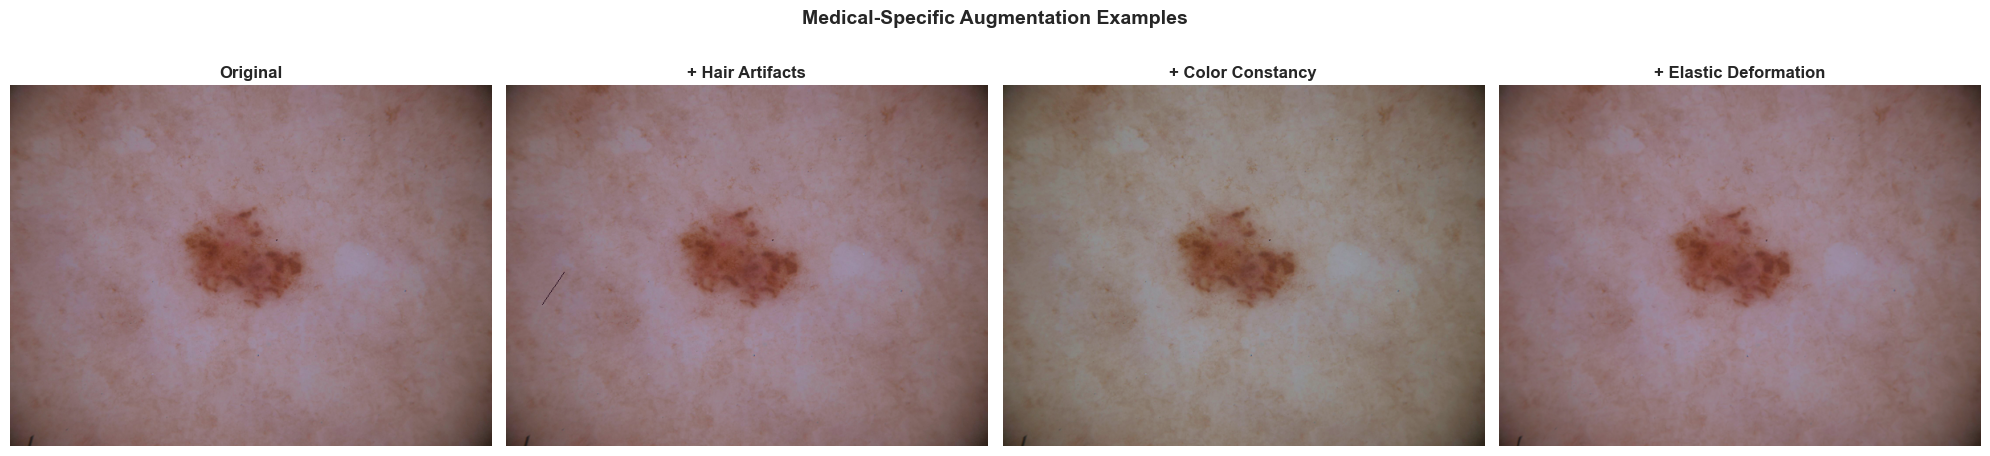


✓ Augmentation examples displayed


In [8]:
"""
4.3 MEDICAL-SPECIFIC AUGMENTATIONS
Custom augmentation classes for dermatoscopic images
"""

print("="*80)
print("4.3 MEDICAL-SPECIFIC AUGMENTATIONS")
print("="*80)

class HairAugmentation:
    """
    Simulates hair artifacts commonly found in dermatoscopic images.
    Draws random dark lines across the image to mimic hair overlays.
    """
    def __init__(self, p=0.3, num_hairs=3):
        self.p = p
        self.num_hairs = num_hairs
    
    def __call__(self, img):
        if np.random.random() > self.p:
            return img
        
        img_np = np.array(img)
        h, w = img_np.shape[:2]
        
        for _ in range(np.random.randint(1, self.num_hairs + 1)):
            # Random start and end points
            x1, y1 = np.random.randint(0, w), np.random.randint(0, h)
            x2, y2 = np.random.randint(0, w), np.random.randint(0, h)
            
            # Dark color (hair is typically dark brown/black)
            color = tuple(np.random.randint(0, 50, 3).tolist())
            
            # Draw line with random thickness
            thickness = np.random.randint(1, 3)
            cv2.line(img_np, (x1, y1), (x2, y2), color, thickness)
        
        return Image.fromarray(img_np)

class ColorConstancyAugmentation:
    """
    Simulates lighting variations in clinical settings.
    Applies different scaling factors to each color channel.
    """
    def __init__(self, p=0.3, scale_range=[0.9, 1.1]):
        self.p = p
        self.scale_range = scale_range
    
    def __call__(self, img):
        if np.random.random() > self.p:
            return img
        
        img_np = np.array(img).astype(np.float32) / 255.0
        
        # Apply different scale to each RGB channel
        scales = [np.random.uniform(*self.scale_range) for _ in range(3)]
        for i in range(3):
            img_np[:, :, i] = np.clip(img_np[:, :, i] * scales[i], 0, 1)
        
        return Image.fromarray((img_np * 255).astype(np.uint8))

class ElasticDeformation:
    """
    Applies elastic deformation while preserving lesion structure.
    Simulates skin elasticity and different patient positioning.
    """
    def __init__(self, p=0.2, alpha=20, sigma=4):
        self.p = p
        self.alpha = alpha
        self.sigma = sigma
    
    def __call__(self, img):
        if np.random.random() > self.p:
            return img
        
        img_np = np.array(img)
        shape = img_np.shape[:2]
        
        # Generate random displacement fields
        dx = gaussian_filter((np.random.rand(*shape) * 2 - 1), self.sigma) * self.alpha
        dy = gaussian_filter((np.random.rand(*shape) * 2 - 1), self.sigma) * self.alpha
        
        # Create coordinate meshgrid
        x, y = np.meshgrid(np.arange(shape[1]), np.arange(shape[0]))
        indices = np.reshape(y + dy, (-1, 1)), np.reshape(x + dx, (-1, 1))
        
        # Apply deformation to each channel
        distorted = np.zeros_like(img_np)
        for i in range(img_np.shape[2]):
            distorted[:, :, i] = map_coordinates(
                img_np[:, :, i], 
                indices, 
                order=1, 
                mode='reflect'
            ).reshape(shape)
        
        return Image.fromarray(distorted)

print("✓ Custom augmentation classes defined:")
print("  - HairAugmentation: Simulates hair artifacts")
print("  - ColorConstancyAugmentation: Simulates lighting variation")
print("  - ElasticDeformation: Preserves lesion structure while deforming")

# Test augmentations on sample image
print("\n" + "-"*80)
print("TESTING AUGMENTATIONS")
print("-"*80)

# FIX: Get sample image correctly from either folder
sample_image_id = train_df.iloc[0]['image_id']

# Check both folders
path1 = DATA_DIR_PART1 / f"{sample_image_id}.jpg"
path2 = DATA_DIR_PART2 / f"{sample_image_id}.jpg"

if path1.exists():
    sample_img_path = path1
elif path2.exists():
    sample_img_path = path2
else:
    # Fallback: try the path from dataframe
    sample_img_path = train_df.iloc[0]['image_path']
    if not os.path.exists(sample_img_path):
        print(f"⚠️ Warning: Could not find sample image {sample_image_id}")
        print("Skipping augmentation visualization...")
        sample_img = None

if sample_img_path and os.path.exists(str(sample_img_path)):
    sample_img = Image.open(sample_img_path).convert('RGB')
    
    # Apply each augmentation
    hair_aug = HairAugmentation(p=1.0)
    color_aug = ColorConstancyAugmentation(p=1.0)
    elastic_aug = ElasticDeformation(p=1.0)
    
    img_with_hair = hair_aug(sample_img)
    img_with_color = color_aug(sample_img)
    img_with_elastic = elastic_aug(sample_img)
    
    # Visualize
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    
    axes[0].imshow(sample_img)
    axes[0].set_title('Original', fontsize=12, fontweight='bold')
    axes[0].axis('off')
    
    axes[1].imshow(img_with_hair)
    axes[1].set_title('+ Hair Artifacts', fontsize=12, fontweight='bold')
    axes[1].axis('off')
    
    axes[2].imshow(img_with_color)
    axes[2].set_title('+ Color Constancy', fontsize=12, fontweight='bold')
    axes[2].axis('off')
    
    axes[3].imshow(img_with_elastic)
    axes[3].set_title('+ Elastic Deformation', fontsize=12, fontweight='bold')
    axes[3].axis('off')
    
    plt.suptitle('Medical-Specific Augmentation Examples', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("\n✓ Augmentation examples displayed")
else:
    print("✓ Augmentation classes ready (visualization skipped)")

In [9]:
"""
4.4 DATA TRANSFORMS SETUP
Define augmentation pipelines for training and validation
"""

print("="*80)
print("4.4 DATA TRANSFORMS")
print("="*80)

# Medical augmentation pipeline (for minority classes)
medical_augment = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    HairAugmentation(p=0.2, num_hairs=2),
    ColorConstancyAugmentation(p=0.3),
    ElasticDeformation(p=0.2, alpha=20, sigma=5),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(180),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Standard augmentation pipeline (for majority classes)
standard_augment = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Validation transform (no augmentation)
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("✓ Augmentation pipelines defined:")
print("\n1. Medical Augmentation (minority classes <500 samples):")
print("   - Resize to 224x224")
print("   - Hair artifacts (p=0.3)")
print("   - Color constancy (p=0.3)")
print("   - Elastic deformation (p=0.2)")
print("   - Random horizontal flip (p=0.5)")
print("   - Random rotation (±20°)")
print("   - Color jitter")
print("   - ImageNet normalization")

print("\n2. Standard Augmentation (majority classes ≥500 samples):")
print("   - Resize to 224x224")
print("   - Random horizontal flip (p=0.5)")
print("   - Random rotation (±10°)")
print("   - ImageNet normalization")

print("\n3. Validation Transform (no augmentation):")
print("   - Resize to 224x224")
print("   - ImageNet normalization only")

4.4 DATA TRANSFORMS
✓ Augmentation pipelines defined:

1. Medical Augmentation (minority classes <500 samples):
   - Resize to 224x224
   - Hair artifacts (p=0.3)
   - Color constancy (p=0.3)
   - Elastic deformation (p=0.2)
   - Random horizontal flip (p=0.5)
   - Random rotation (±20°)
   - Color jitter
   - ImageNet normalization

2. Standard Augmentation (majority classes ≥500 samples):
   - Resize to 224x224
   - Random horizontal flip (p=0.5)
   - Random rotation (±10°)
   - ImageNet normalization

3. Validation Transform (no augmentation):
   - Resize to 224x224
   - ImageNet normalization only


In [10]:
"""
4.5 CUSTOM DATASET CLASS
Adaptive augmentation based on class frequency
"""

print("="*80)
print("4.5 CUSTOM DATASET WITH ADAPTIVE AUGMENTATION")
print("="*80)

class MedicalDataset(Dataset):
    """
    Custom Dataset that applies different augmentation strategies
    based on class frequency (minority vs majority classes).
    
    Key Feature: Classes with <500 samples get stronger augmentation.
    """
    def __init__(self, dataframe, transform=None, is_training=False, minority_threshold=500):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.is_training = is_training
        
        if is_training:
            # Identify minority classes (require strong augmentation)
            class_counts = dataframe['label'].value_counts()
            self.minority_classes = set(
                class_counts[class_counts < minority_threshold].index.tolist()
            )
            print(f"Minority classes (<{minority_threshold} samples): {self.minority_classes}")
            
            # Count samples per type
            majority_count = sum(1 for label in dataframe['label'] if label not in self.minority_classes)
            minority_count = len(dataframe) - majority_count
            print(f"Majority class samples: {majority_count:,}")
            print(f"Minority class samples: {minority_count:,}")
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        img_path = self.df.loc[idx, 'image_path']
        label = self.df.loc[idx, 'label']
        
        # Load image
        image = Image.open(img_path).convert('RGB')
        
        # Apply augmentation based on class frequency
        if self.is_training:
            if label in self.minority_classes:
                # Strong augmentation for minority classes
                image = medical_augment(image)
            else:
                # Standard augmentation for majority classes
                image = standard_augment(image)
        else:
            # Validation/test: no augmentation
            if self.transform:
                image = self.transform(image)
        
        return image, label

# Create datasets
print("\n" + "-"*80)
print("CREATING DATASETS")
print("-"*80)

train_dataset = MedicalDataset(train_df, is_training=True, minority_threshold=500)
val_dataset = MedicalDataset(val_df, transform=val_transform, is_training=False)
test_dataset = MedicalDataset(test_df, transform=val_transform, is_training=False)

print(f"\n✓ Training dataset: {len(train_dataset):,} samples")
print(f"✓ Validation dataset: {len(val_dataset):,} samples")
print(f"✓ Test dataset: {len(test_dataset):,} samples")

# Create weighted sampler for training
weighted_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

print(f"\n✓ Weighted sampler created for balanced batch sampling")

4.5 CUSTOM DATASET WITH ADAPTIVE AUGMENTATION

--------------------------------------------------------------------------------
CREATING DATASETS
--------------------------------------------------------------------------------
Minority classes (<500 samples): {0, 1, 3, 6}
Majority class samples: 6,241
Minority class samples: 768

✓ Training dataset: 7,009 samples
✓ Validation dataset: 1,503 samples
✓ Test dataset: 1,503 samples

✓ Weighted sampler created for balanced batch sampling


UPDATING IMAGE PATHS
✓ Train paths verified: 7009/7009
✓ Val paths verified: 1503/1503
✓ Test paths verified: 1503/1503
Minority classes (<500 samples): {0, 1, 3, 6}
Majority class samples: 6,241
Minority class samples: 768

✓ Datasets recreated with correct paths

4.6 CREATING DATALOADERS
✓ Training loader: 220 batches of 32
✓ Validation loader: 47 batches of 32
✓ Test loader: 47 batches of 32

--------------------------------------------------------------------------------
TESTING BATCH LOADING
--------------------------------------------------------------------------------
Batch shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])
Labels in batch: [1, 4, 0, 1, 4, 5, 1, 4, 3, 5, 1, 1, 6, 6, 5, 1, 0, 1, 4, 0, 1, 1, 0, 5, 2, 3, 4, 6, 5, 5, 2, 4]
Unique classes in batch: 7/7


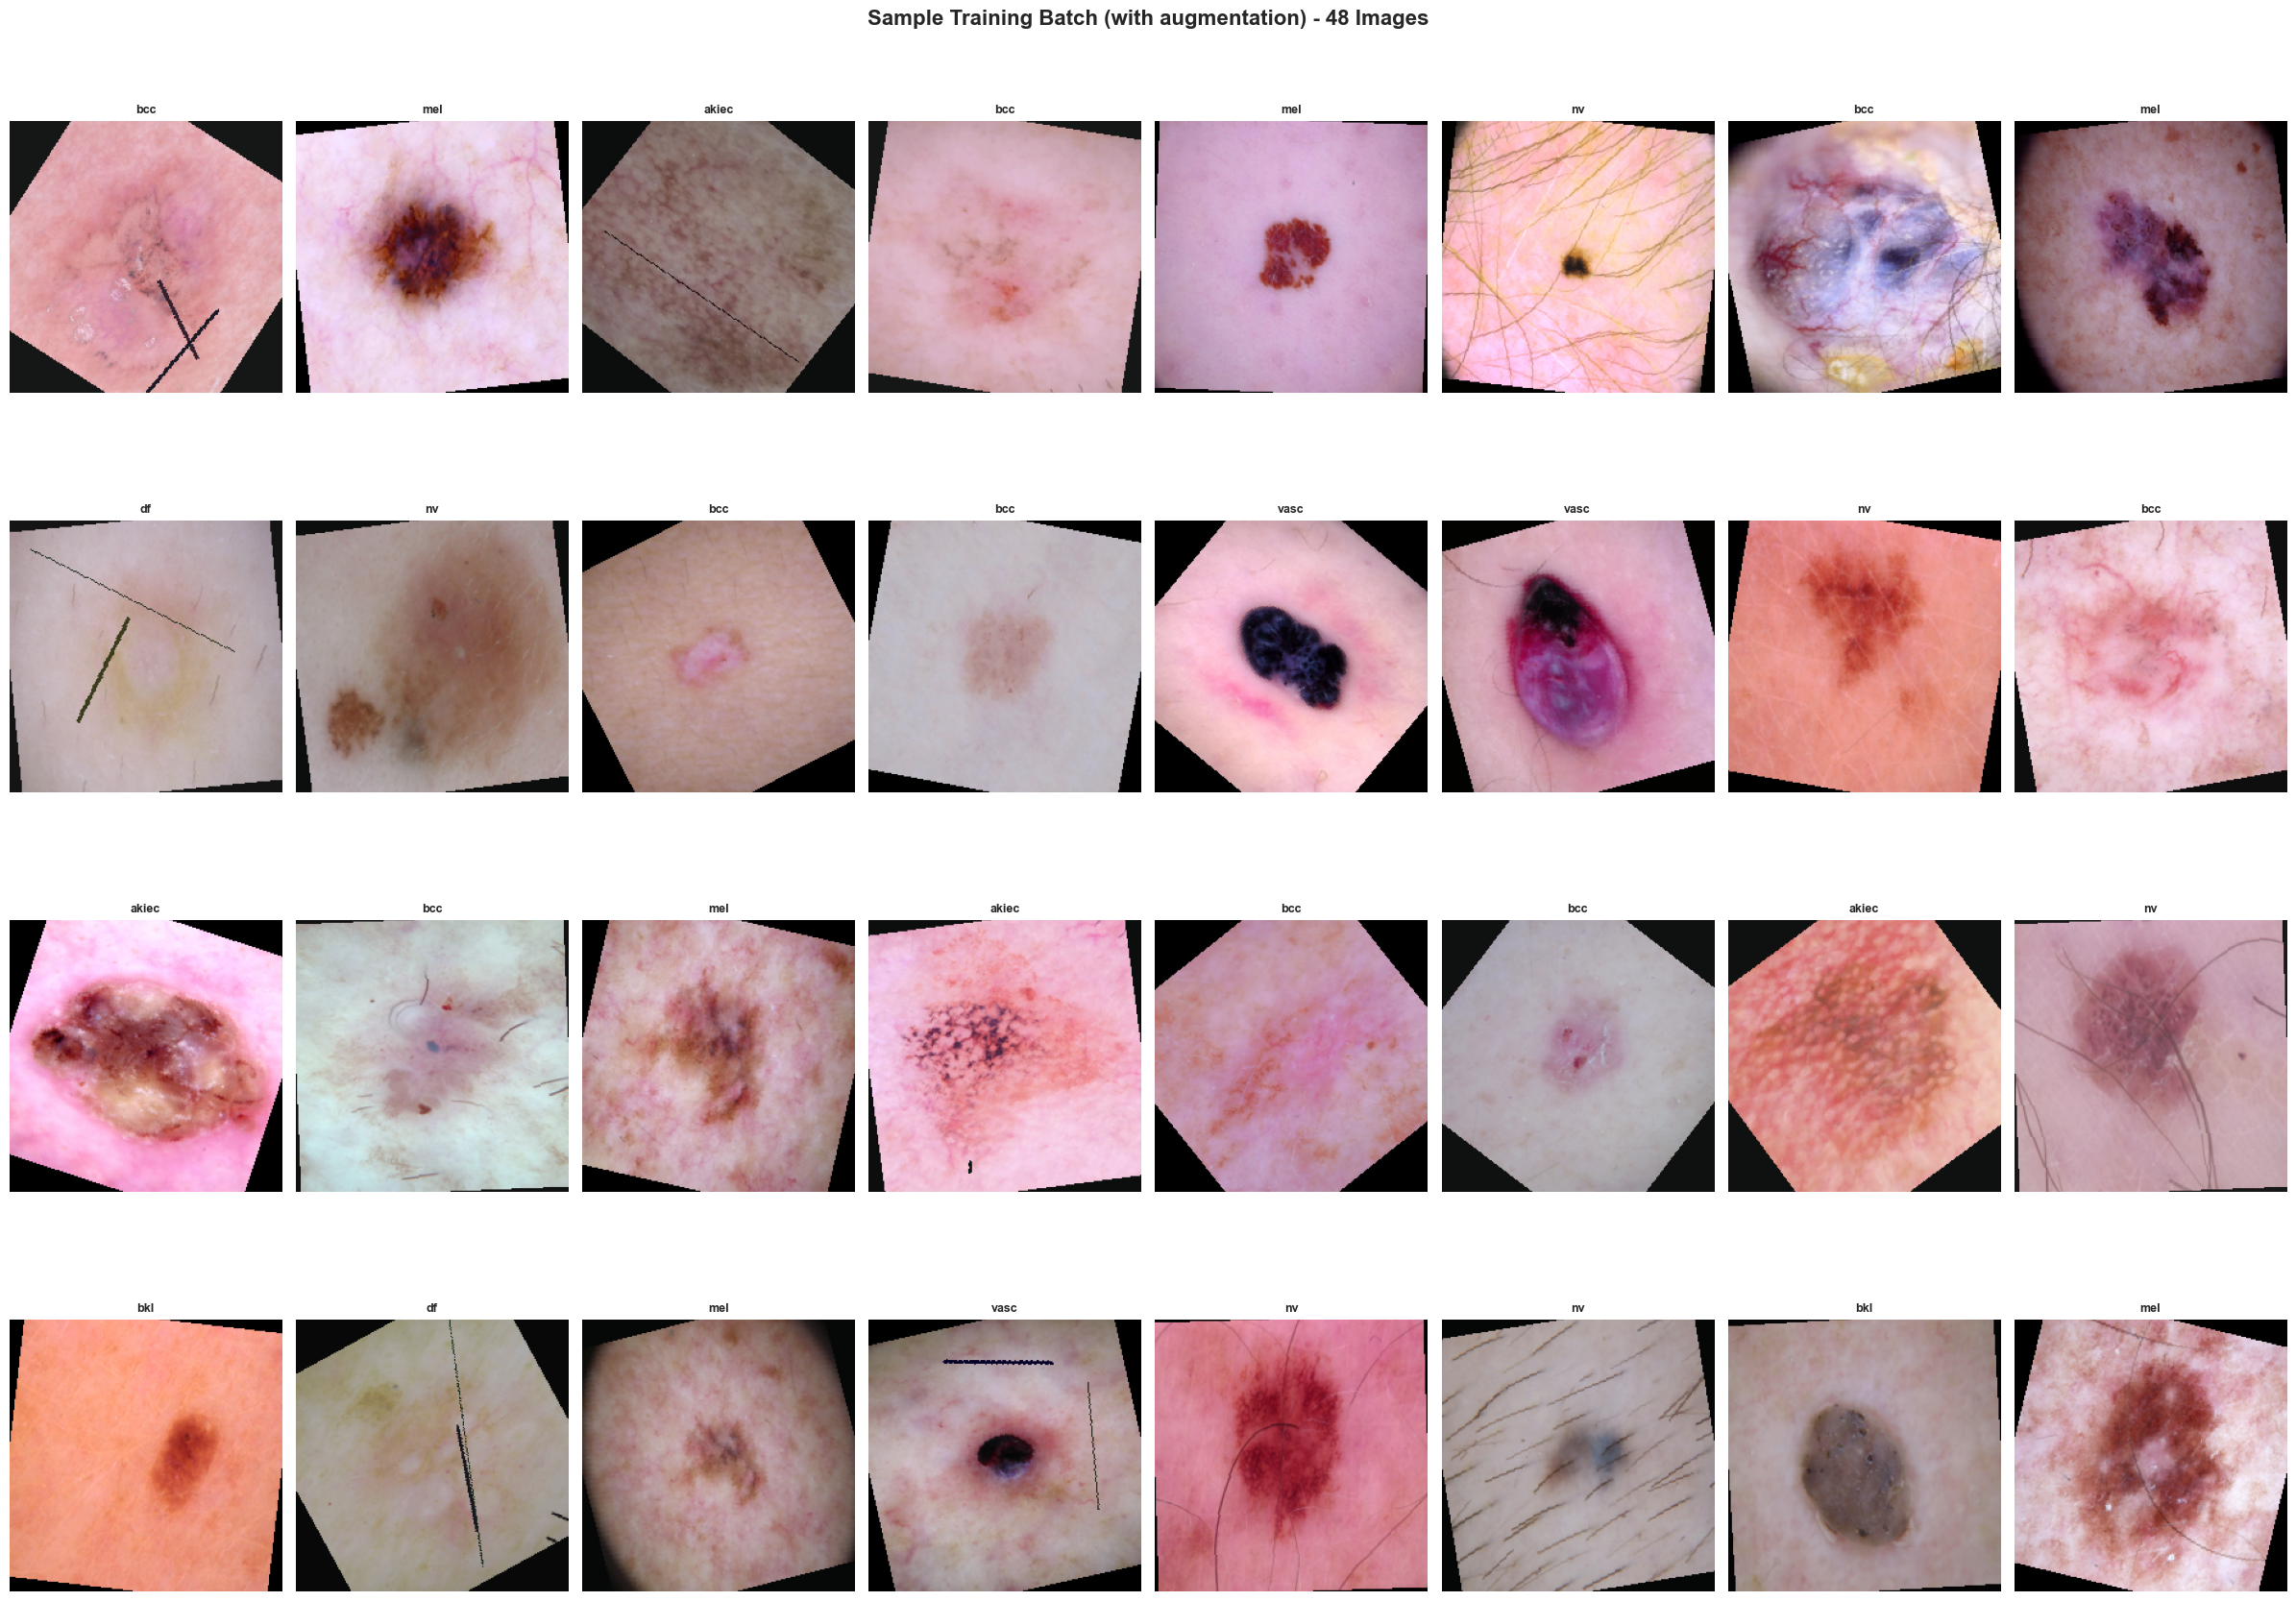


✓ Displayed 32 sample images from training batch
✓ Data pipeline ready for training

DATA PREPROCESSING COMPLETE


In [11]:
"""
4.6 CREATE DATALOADERS
"""

# UPDATE PATHS IN DATAFRAMES
print("="*80)
print("UPDATING IMAGE PATHS")
print("="*80)

from pathlib import Path

DATA_DIR_PART1 = Path('data/raw/HAM10000_images_part_1')
DATA_DIR_PART2 = Path('data/raw/HAM10000_images_part_2')

def get_correct_image_path(image_id):
    """Find correct path for image_id"""
    path1 = DATA_DIR_PART1 / f"{image_id}.jpg"
    path2 = DATA_DIR_PART2 / f"{image_id}.jpg"
    
    if path1.exists():
        return str(path1)
    elif path2.exists():
        return str(path2)
    else:
        return str(path1)  # fallback

# Update paths in all dataframes
train_df['image_path'] = train_df['image_id'].apply(get_correct_image_path)
val_df['image_path'] = val_df['image_id'].apply(get_correct_image_path)
test_df['image_path'] = test_df['image_id'].apply(get_correct_image_path)

# Verify paths
valid_train = train_df['image_path'].apply(lambda x: os.path.exists(x)).sum()
valid_val = val_df['image_path'].apply(lambda x: os.path.exists(x)).sum()
valid_test = test_df['image_path'].apply(lambda x: os.path.exists(x)).sum()

print(f"✓ Train paths verified: {valid_train}/{len(train_df)}")
print(f"✓ Val paths verified: {valid_val}/{len(val_df)}")
print(f"✓ Test paths verified: {valid_test}/{len(test_df)}")

# Recreate datasets with updated paths
train_dataset = MedicalDataset(train_df, is_training=True, minority_threshold=500)
val_dataset = MedicalDataset(val_df, transform=val_transform, is_training=False)
test_dataset = MedicalDataset(test_df, transform=val_transform, is_training=False)

print("\n✓ Datasets recreated with correct paths")

# NOW CREATE LOADERS
print("\n" + "="*80)
print("4.6 CREATING DATALOADERS")
print("="*80)

# Training loader with weighted sampling
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=weighted_sampler,  # Use weighted sampler instead of shuffle
    num_workers=0, 
    pin_memory=True if torch.cuda.is_available() else False
)

# Validation loader
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True if torch.cuda.is_available() else False
)

# Test loader
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True if torch.cuda.is_available() else False
)

print(f"✓ Training loader: {len(train_loader)} batches of {BATCH_SIZE}")
print(f"✓ Validation loader: {len(val_loader)} batches of {BATCH_SIZE}")
print(f"✓ Test loader: {len(test_loader)} batches of {BATCH_SIZE}")

# Test batch loading
print("\n" + "-"*80)
print("TESTING BATCH LOADING")
print("-"*80)

images, labels = next(iter(train_loader))
print(f"Batch shape: {images.shape}")
print(f"Labels shape: {labels.shape}")
print(f"Labels in batch: {labels.tolist()}")
print(f"Unique classes in batch: {len(torch.unique(labels))}/{NUM_CLASSES}")

# Visualize batch 
fig, axes = plt.subplots(4, 8, figsize=(24, 18))
axes = axes.flatten()

num_display = min(32, len(images))  

for idx in range(num_display):
    # Denormalize image for display
    img = images[idx].cpu().numpy().transpose(1, 2, 0)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    
    label = labels[idx].item()
    class_name = le.inverse_transform([label])[0]
    
    axes[idx].imshow(img)
    axes[idx].set_title(f"{class_name}", fontsize=9, fontweight='bold')
    axes[idx].axis('off')

# Hide unused subplots
for idx in range(num_display, len(axes)):
    axes[idx].axis('off')

plt.suptitle('Sample Training Batch (with augmentation) - 48 Images', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n✓ Displayed {num_display} sample images from training batch")
print("✓ Data pipeline ready for training")
print("\n" + "="*80)
print("DATA PREPROCESSING COMPLETE")
print("="*80)

In [12]:
"""
=============================================================================
SECTION 5: BASELINE MODELS - TRAINING UTILITIES
=============================================================================
Define reusable training and validation functions
"""

print("="*80)
print("TRAINING UTILITY FUNCTIONS")
print("="*80)

def train_epoch(model, loader, criterion, optimizer, device):
    """
    Train model for one epoch
    
    Returns:
        avg_loss: Average training loss
        accuracy: Training accuracy
    """
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    pbar = tqdm(loader, desc='Training', leave=False)
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        # Metrics
        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        
        # Update progress bar
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    avg_loss = running_loss / len(loader)
    accuracy = accuracy_score(all_labels, all_preds)
    
    return avg_loss, accuracy

def validate(model, loader, criterion, device):
    """
    Validate model
    
    Returns:
        avg_loss: Average validation loss
        accuracy: Validation accuracy
        precision: Weighted precision
        recall: Weighted recall
        f1: Weighted F1-score
    """
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        pbar = tqdm(loader, desc='Validating', leave=False)
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)
            
            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            # Metrics
            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    avg_loss = running_loss / len(loader)
    accuracy = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='weighted', zero_division=0
    )
    
    return avg_loss, accuracy, precision, recall, f1

def unfreeze_layer(model, layer_name):
    """
    Unfreeze a specific layer for fine-tuning
    """
    layer = getattr(model, layer_name, None)
    if layer is not None:
        for param in layer.parameters():
            param.requires_grad = True
        
        trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
        total = sum(p.numel() for p in model.parameters())
        print(f"   Unfroze {layer_name}")
        print(f"   Trainable parameters: {trainable:,} / {total:,} ({trainable/total*100:.1f}%)")
    else:
        print(f"   Warning: Layer {layer_name} not found")

print("✓ Training utilities defined:")
print("  - train_epoch(): Train for one epoch with gradient clipping")
print("  - validate(): Evaluate on validation set")
print("  - unfreeze_layer(): Progressive layer unfreezing")

TRAINING UTILITY FUNCTIONS
✓ Training utilities defined:
  - train_epoch(): Train for one epoch with gradient clipping
  - validate(): Evaluate on validation set
  - unfreeze_layer(): Progressive layer unfreezing


5.1 RESNET50 BASELINE TRAINING
Building ResNet50 baseline...

Model Architecture:
  Total parameters: 24,560,711
  Trainable parameters: 1,052,679 (4.3%)
  Frozen parameters: 23,508,032

Training Configuration:
  Optimizer: Adam (lr=0.001)
  Loss: CrossEntropyLoss with effective number class weights
  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)
  Epochs: 40 (NO early stopping for baseline)
  Batch size: 32

--------------------------------------------------------------------------------
TRAINING RESNET50 BASELINE (Full 40 epochs)
--------------------------------------------------------------------------------

Epoch 1/40
----------------------------------------


Training:   0%|          | 0/220 [00:00<?, ?it/s]

Validating:   0%|          | 0/47 [00:00<?, ?it/s]

Train Loss: 0.9716, Train Acc: 0.3741
Val Loss: 1.4211, Val Acc: 0.2908, Val F1: 0.3402
✓ Saved best model (F1: 0.3402)

Epoch 2/40
----------------------------------------


Training:   0%|          | 0/220 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/47 [00:00<?, ?it/s]

Train Loss: 0.4350, Train Acc: 0.6766
Val Loss: 0.9900, Val Acc: 0.5941, Val F1: 0.6392
✓ Saved best model (F1: 0.6392)

Epoch 40/40
----------------------------------------


Training:   0%|          | 0/220 [00:00<?, ?it/s]

Validating:   0%|          | 0/47 [00:00<?, ?it/s]

Train Loss: 0.4294, Train Acc: 0.6833
Val Loss: 1.0220, Val Acc: 0.5336, Val F1: 0.5911

RESNET50 BASELINE TRAINING COMPLETE
Training time: 70.6 minutes
Best validation F1: 0.6392 (Epoch 39)
Final validation F1: 0.5911


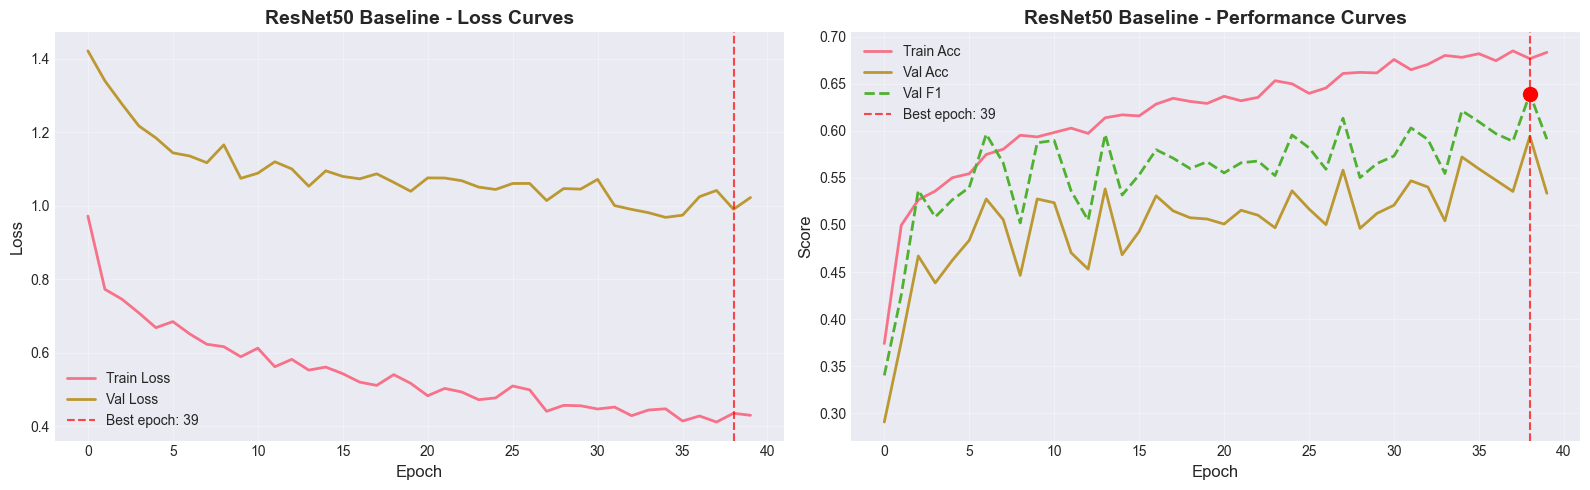


✓ Learning curves saved


In [13]:
"""
5.1 RESNET50 BASELINE (FROZEN BACKBONE)
Let it train fully to establish proper baseline
"""

print("="*80)
print("5.1 RESNET50 BASELINE TRAINING")
print("="*80)

# Build model
print("Building ResNet50 baseline...")
resnet50_baseline = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

# Freeze all backbone layers
for param in resnet50_baseline.parameters():
    param.requires_grad = False

# Replace classifier head
resnet50_baseline.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(2048, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, NUM_CLASSES)
)

resnet50_baseline = resnet50_baseline.to(DEVICE)

# Model summary
total_params = sum(p.numel() for p in resnet50_baseline.parameters())
trainable_params = sum(p.numel() for p in resnet50_baseline.parameters() if p.requires_grad)

print(f"\nModel Architecture:")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,} ({trainable_params/total_params*100:.1f}%)")
print(f"  Frozen parameters: {total_params - trainable_params:,}")

# Training setup
criterion = nn.CrossEntropyLoss(weight=class_weights_effective_tensor)
optimizer = optim.Adam(resnet50_baseline.fc.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=5, verbose=True)

print(f"\nTraining Configuration:")
print(f"  Optimizer: Adam (lr=0.001)")
print(f"  Loss: CrossEntropyLoss with effective number class weights")
print(f"  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)")
print(f"  Epochs: 40 (NO early stopping for baseline)")
print(f"  Batch size: {BATCH_SIZE}")

# Training loop
print("\n" + "-"*80)
print("TRAINING RESNET50 BASELINE (Full 40 epochs)")
print("-"*80)

num_epochs_baseline = 40
history_baseline = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': [], 'val_f1': []
}

best_f1 = 0.0
best_epoch = 0

start_time = time.time()

for epoch in range(num_epochs_baseline):
    print(f"\nEpoch {epoch+1}/{num_epochs_baseline}")
    print("-" * 40)
    
    # Train
    train_loss, train_acc = train_epoch(
        resnet50_baseline, train_loader, criterion, optimizer, DEVICE
    )
    
    # Validate
    val_loss, val_acc, val_p, val_r, val_f1 = validate(
        resnet50_baseline, val_loader, criterion, DEVICE
    )
    
    # Update scheduler
    scheduler.step(val_loss)
    
    # Store history
    history_baseline['train_loss'].append(train_loss)
    history_baseline['train_acc'].append(train_acc)
    history_baseline['val_loss'].append(val_loss)
    history_baseline['val_acc'].append(val_acc)
    history_baseline['val_f1'].append(val_f1)
    
    # Print metrics
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, Val F1: {val_f1:.4f}")
    
    # Save best model (but don't stop)
    if val_f1 > best_f1:
        best_f1 = val_f1
        best_epoch = epoch + 1
        torch.save(resnet50_baseline.state_dict(), 'resnet50_baseline_best.pth')
        print(f"✓ Saved best model (F1: {val_f1:.4f})")

training_time = time.time() - start_time
print(f"\n" + "="*80)
print(f"RESNET50 BASELINE TRAINING COMPLETE")
print(f"="*80)
print(f"Training time: {training_time/60:.1f} minutes")
print(f"Best validation F1: {best_f1:.4f} (Epoch {best_epoch})")
print(f"Final validation F1: {history_baseline['val_f1'][-1]:.4f}")

# Save history
with open('resnet50_baseline_history.json', 'w') as f:
    json.dump(history_baseline, f, indent=2)

# Plot learning curves
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Loss
axes[0].plot(history_baseline['train_loss'], label='Train Loss', linewidth=2)
axes[0].plot(history_baseline['val_loss'], label='Val Loss', linewidth=2)
axes[0].axvline(x=best_epoch-1, color='red', linestyle='--', alpha=0.7, label=f'Best epoch: {best_epoch}')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('ResNet50 Baseline - Loss Curves', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(history_baseline['train_acc'], label='Train Acc', linewidth=2)
axes[1].plot(history_baseline['val_acc'], label='Val Acc', linewidth=2)
axes[1].plot(history_baseline['val_f1'], label='Val F1', linewidth=2, linestyle='--')
axes[1].axvline(x=best_epoch-1, color='red', linestyle='--', alpha=0.7, label=f'Best epoch: {best_epoch}')
axes[1].scatter([best_epoch-1], [best_f1], color='red', s=100, zorder=5)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Score', fontsize=12)
axes[1].set_title('ResNet50 Baseline - Performance Curves', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Learning curves saved")

5.2 EFFICIENTNET-B0 BASELINE TRAINING
Building EfficientNet-B0 baseline...

Model Architecture:
  Total parameters: 4,667,011
  Trainable parameters: 659,463 (14.1%)
  Frozen parameters: 4,007,548

Training Configuration:
  Optimizer: Adam (lr=0.001)
  Loss: CrossEntropyLoss with effective number class weights
  Scheduler: ReduceLROnPlateau (factor=0.5, patience=3)
  Epochs: 15 (with early stopping)

--------------------------------------------------------------------------------
TRAINING EFFICIENTNET-B0 BASELINE
--------------------------------------------------------------------------------

Epoch 1/15
----------------------------------------


Training:   0%|          | 0/220 [00:00<?, ?it/s]

Validating:   0%|          | 0/47 [00:00<?, ?it/s]

Train Loss: 0.9405, Train Acc: 0.4002
Val Loss: 1.6695, Val Acc: 0.1497, Val F1: 0.1130
✓ Saved best model (F1: 0.1130)

Epoch 2/15
----------------------------------------


Training:   0%|          | 0/220 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/47 [00:00<?, ?it/s]

Train Loss: 0.5194, Train Acc: 0.6205
Val Loss: 1.3540, Val Acc: 0.3520, Val F1: 0.3909

Epoch 14/15
----------------------------------------


Training:   0%|          | 0/220 [00:00<?, ?it/s]

Validating:   0%|          | 0/47 [00:00<?, ?it/s]

Train Loss: 0.5079, Train Acc: 0.6258
Val Loss: 1.3139, Val Acc: 0.3912, Val F1: 0.4340

Early stopping triggered (patience=5)

EFFICIENTNET-B0 BASELINE TRAINING COMPLETE
Training time: 23.4 minutes
Best validation F1: 0.4776


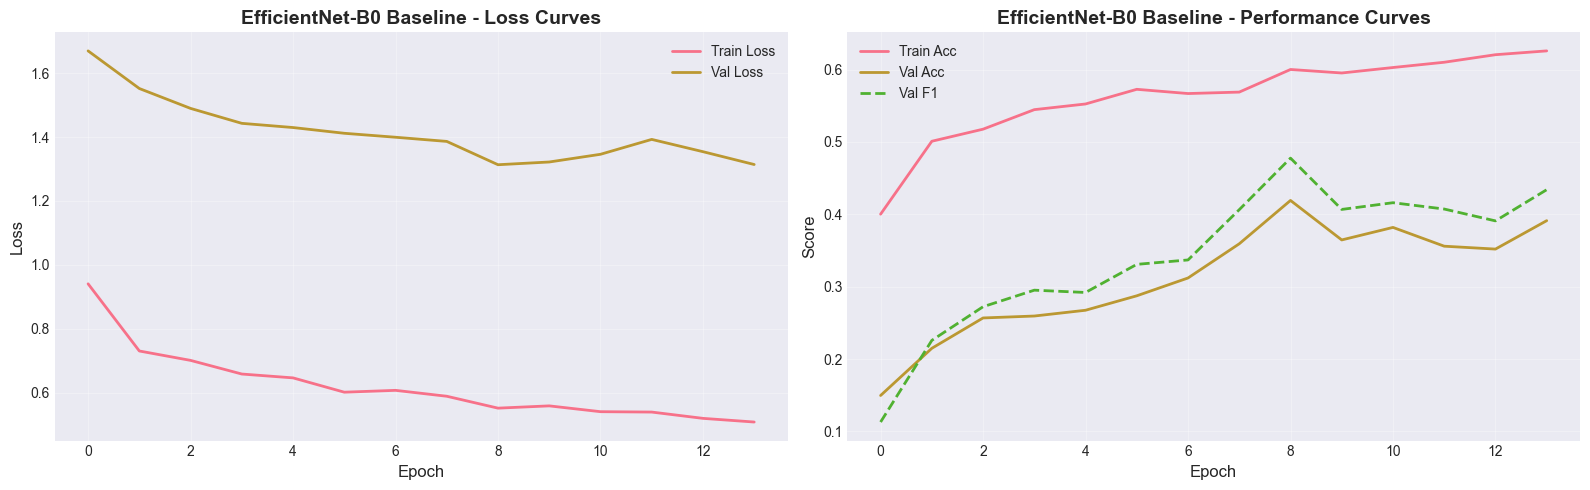


✓ Learning curves saved


In [14]:
"""
5.2 EFFICIENTNET-B0 BASELINE (FROZEN BACKBONE)
Train classifier only with frozen EfficientNet-B0 backbone
"""

print("="*80)
print("5.2 EFFICIENTNET-B0 BASELINE TRAINING")
print("="*80)

# Build model
print("Building EfficientNet-B0 baseline...")
effnet_baseline = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

# Freeze all backbone layers
for param in effnet_baseline.features.parameters():
    param.requires_grad = False

# Replace classifier head
effnet_baseline.classifier = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(1280, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, NUM_CLASSES)
)

effnet_baseline = effnet_baseline.to(DEVICE)

# Model summary
total_params = sum(p.numel() for p in effnet_baseline.parameters())
trainable_params = sum(p.numel() for p in effnet_baseline.parameters() if p.requires_grad)

print(f"\nModel Architecture:")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,} ({trainable_params/total_params*100:.1f}%)")
print(f"  Frozen parameters: {total_params - trainable_params:,}")

# Training setup
criterion = nn.CrossEntropyLoss(weight=class_weights_effective_tensor)
optimizer = optim.Adam(effnet_baseline.classifier.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=3, verbose=True)

print(f"\nTraining Configuration:")
print(f"  Optimizer: Adam (lr=0.001)")
print(f"  Loss: CrossEntropyLoss with effective number class weights")
print(f"  Scheduler: ReduceLROnPlateau (factor=0.5, patience=3)")
print(f"  Epochs: 15 (with early stopping)")

# Training loop
print("\n" + "-"*80)
print("TRAINING EFFICIENTNET-B0 BASELINE")
print("-"*80)

num_epochs_effnet_baseline = 15
history_effnet_baseline = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': [], 'val_f1': []
}

best_f1 = 0.0
patience_counter = 0
max_patience = 5

start_time = time.time()

for epoch in range(num_epochs_effnet_baseline):
    print(f"\nEpoch {epoch+1}/{num_epochs_effnet_baseline}")
    print("-" * 40)
    
    # Train
    train_loss, train_acc = train_epoch(
        effnet_baseline, train_loader, criterion, optimizer, DEVICE
    )
    
    # Validate
    val_loss, val_acc, val_p, val_r, val_f1 = validate(
        effnet_baseline, val_loader, criterion, DEVICE
    )
    
    # Update scheduler
    scheduler.step(val_loss)
    
    # Store history
    history_effnet_baseline['train_loss'].append(train_loss)
    history_effnet_baseline['train_acc'].append(train_acc)
    history_effnet_baseline['val_loss'].append(val_loss)
    history_effnet_baseline['val_acc'].append(val_acc)
    history_effnet_baseline['val_f1'].append(val_f1)
    
    # Print metrics
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, Val F1: {val_f1:.4f}")
    
    # Save best model
    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(effnet_baseline.state_dict(), 'efficientnet_baseline_best.pth')
        print(f"✓ Saved best model (F1: {val_f1:.4f})")
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= max_patience:
            print(f"\nEarly stopping triggered (patience={max_patience})")
            break

training_time = time.time() - start_time
print(f"\n" + "="*80)
print(f"EFFICIENTNET-B0 BASELINE TRAINING COMPLETE")
print(f"="*80)
print(f"Training time: {training_time/60:.1f} minutes")
print(f"Best validation F1: {best_f1:.4f}")

# Save history
with open('efficientnet_baseline_history.json', 'w') as f:
    json.dump(history_effnet_baseline, f, indent=2)

# Plot learning curves
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Loss
axes[0].plot(history_effnet_baseline['train_loss'], label='Train Loss', linewidth=2)
axes[0].plot(history_effnet_baseline['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('EfficientNet-B0 Baseline - Loss Curves', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(history_effnet_baseline['train_acc'], label='Train Acc', linewidth=2)
axes[1].plot(history_effnet_baseline['val_acc'], label='Val Acc', linewidth=2)
axes[1].plot(history_effnet_baseline['val_f1'], label='Val F1', linewidth=2, linestyle='--')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Score', fontsize=12)
axes[1].set_title('EfficientNet-B0 Baseline - Performance Curves', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Learning curves saved")

5.3 BASELINE MODELS EVALUATION
Loading best baseline models...
✓ Models loaded

--------------------------------------------------------------------------------
EVALUATING ON VALIDATION SET
--------------------------------------------------------------------------------


Evaluating ResNet50 Baseline:   0%|          | 0/47 [00:00<?, ?it/s]

Evaluating EfficientNet-B0 Baseline:   0%|          | 0/47 [00:00<?, ?it/s]


BASELINE MODELS COMPARISON

                   Model Accuracy Precision Recall F1-Score    AUC
       ResNet50 Baseline   59.41%    0.7705 0.5941   0.6392 0.9111
EfficientNet-B0 Baseline   41.92%    0.7594 0.4192   0.4776 0.8631


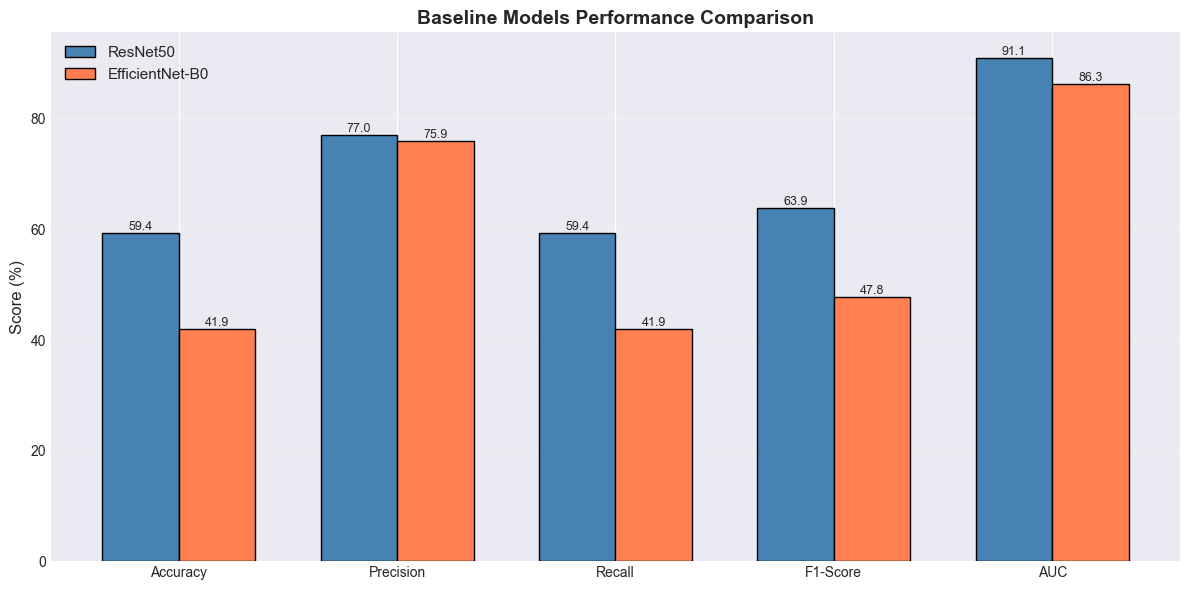


✓ Baseline models comparison complete


In [34]:
"""
5.3 BASELINE MODELS - VALIDATION SET EVALUATION
Compare both baseline models on validation set
"""

print("="*80)
print("5.3 BASELINE MODELS EVALUATION")
print("="*80)

# Load best models
print("Loading best baseline models...")
resnet50_baseline.load_state_dict(torch.load('resnet50_baseline_best.pth', weights_only=True))
effnet_baseline.load_state_dict(torch.load('efficientnet_baseline_best.pth', weights_only=True))

resnet50_baseline.eval()
effnet_baseline.eval()

print("✓ Models loaded")

# Evaluate both models
print("\n" + "-"*80)
print("EVALUATING ON VALIDATION SET")
print("-"*80)

def detailed_evaluate(model, loader, device, model_name):
    """Detailed evaluation with all metrics"""
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for images, labels in tqdm(loader, desc=f'Evaluating {model_name}'):
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())
    
    # Calculate metrics
    acc = accuracy_score(all_labels, all_preds)
    p, r, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='weighted', zero_division=0
    )
    
    # Per-class metrics
    per_class_p, per_class_r, per_class_f1, support = precision_recall_fscore_support(
        all_labels, all_preds, average=None, zero_division=0
    )
    
    # AUC
    auc_score = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='weighted')
    
    return {
        'accuracy': acc,
        'precision': p,
        'recall': r,
        'f1': f1,
        'auc': auc_score,
        'per_class_p': per_class_p,
        'per_class_r': per_class_r,
        'per_class_f1': per_class_f1,
        'support': support,
        'predictions': all_preds,
        'labels': all_labels,
        'probabilities': all_probs
    }

# Evaluate models
resnet50_results = detailed_evaluate(resnet50_baseline, val_loader, DEVICE, 'ResNet50 Baseline')
effnet_results = detailed_evaluate(effnet_baseline, val_loader, DEVICE, 'EfficientNet-B0 Baseline')

# Print results
print("\n" + "="*80)
print("BASELINE MODELS COMPARISON")
print("="*80)

comparison_data = {
    'Model': ['ResNet50 Baseline', 'EfficientNet-B0 Baseline'],
    'Accuracy': [f"{resnet50_results['accuracy']*100:.2f}%", f"{effnet_results['accuracy']*100:.2f}%"],
    'Precision': [f"{resnet50_results['precision']:.4f}", f"{effnet_results['precision']:.4f}"],
    'Recall': [f"{resnet50_results['recall']:.4f}", f"{effnet_results['recall']:.4f}"],
    'F1-Score': [f"{resnet50_results['f1']:.4f}", f"{effnet_results['f1']:.4f}"],
    'AUC': [f"{resnet50_results['auc']:.4f}", f"{effnet_results['auc']:.4f}"]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + comparison_df.to_string(index=False))

# Bar chart comparison
fig, ax = plt.subplots(figsize=(12, 6))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
resnet50_vals = [
    resnet50_results['accuracy']*100,
    resnet50_results['precision']*100,
    resnet50_results['recall']*100,
    resnet50_results['f1']*100,
    resnet50_results['auc']*100
]
effnet_vals = [
    effnet_results['accuracy']*100,
    effnet_results['precision']*100,
    effnet_results['recall']*100,
    effnet_results['f1']*100,
    effnet_results['auc']*100
]

x = np.arange(len(metrics))
width = 0.35

bars1 = ax.bar(x - width/2, resnet50_vals, width, label='ResNet50', color='steelblue', edgecolor='black')
bars2 = ax.bar(x + width/2, effnet_vals, width, label='EfficientNet-B0', color='coral', edgecolor='black')

ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('Baseline Models Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\n✓ Baseline models comparison complete")

5.4 PER-CLASS PERFORMANCE ANALYSIS (BASELINES)

               Class  Code  Support ResNet50 F1 EfficientNet F1
   Actinic keratoses akiec       49       0.451           0.267
Basal cell carcinoma   bcc       77       0.476           0.365
    Benign keratosis   bkl      165       0.484           0.455
      Dermatofibroma    df       18       0.262           0.131
            Melanoma   mel      167       0.377           0.371
    Melanocytic nevi    nv     1006       0.740           0.531
    Vascular lesions  vasc       21       0.466           0.173


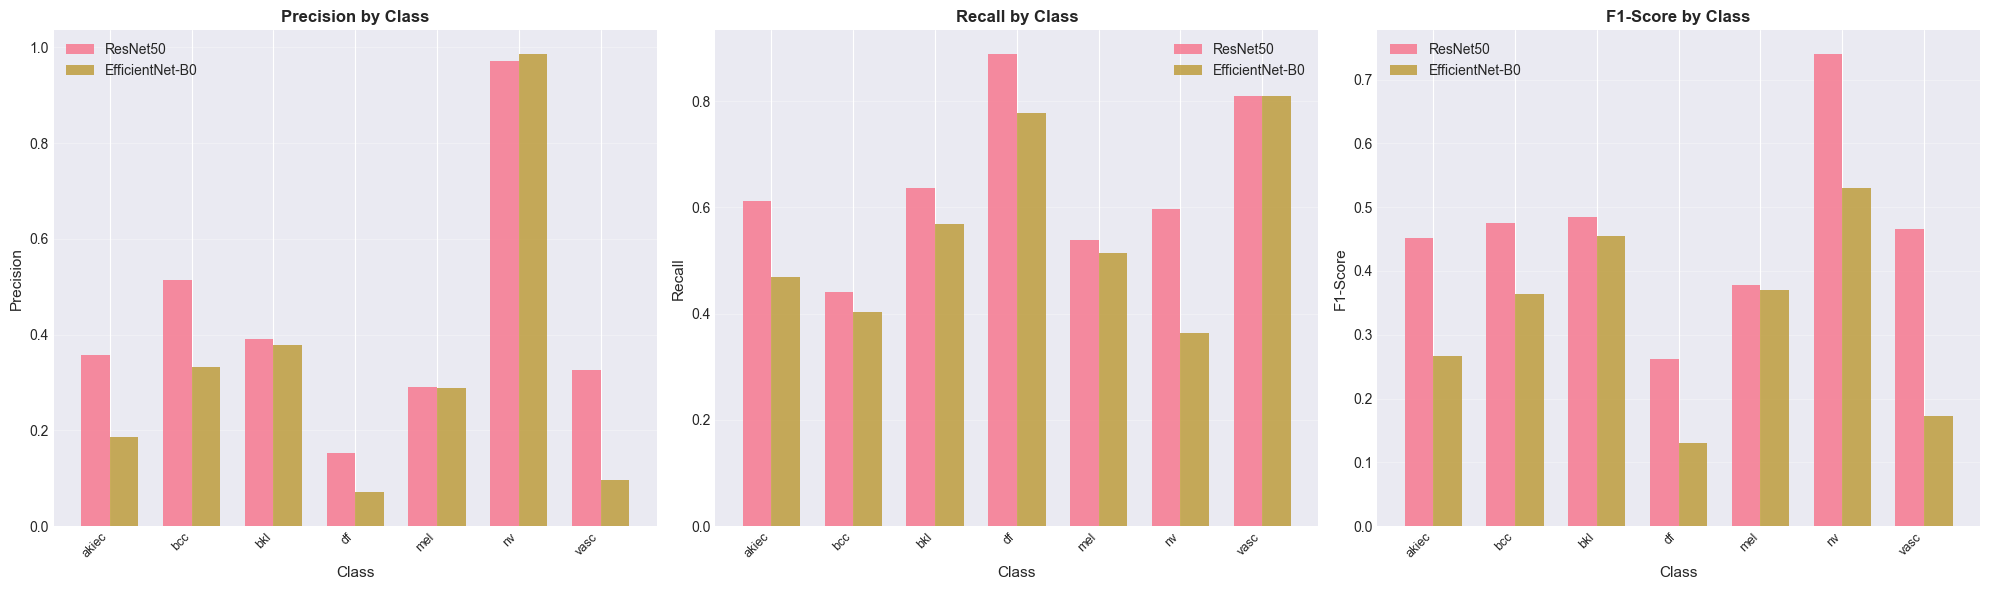


--------------------------------------------------------------------------------
KEY OBSERVATIONS:
--------------------------------------------------------------------------------

ResNet50 Baseline:
  Best class: Melanocytic nevi (F1: 0.740)
  Worst class: Dermatofibroma (F1: 0.262)

EfficientNet-B0 Baseline:
  Best class: Melanocytic nevi (F1: 0.531)
  Worst class: Dermatofibroma (F1: 0.131)

✓ Per-class analysis complete

BASELINE MODELS EVALUATION COMPLETE


In [16]:
"""
5.4 BASELINE MODELS - PER-CLASS PERFORMANCE ANALYSIS
"""

print("="*80)
print("5.4 PER-CLASS PERFORMANCE ANALYSIS (BASELINES)")
print("="*80)

# Create per-class comparison table
class_names_list = [le.inverse_transform([i])[0] for i in range(NUM_CLASSES)]

per_class_data = []
for i in range(NUM_CLASSES):
    per_class_data.append({
        'Class': CLASS_NAMES[class_names_list[i]],
        'Code': class_names_list[i],
        'Support': int(resnet50_results['support'][i]),
        'ResNet50 F1': f"{resnet50_results['per_class_f1'][i]:.3f}",
        'EfficientNet F1': f"{effnet_results['per_class_f1'][i]:.3f}"
    })

per_class_df = pd.DataFrame(per_class_data)
print("\n" + per_class_df.to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

metrics_names = ['Precision', 'Recall', 'F1-Score']
resnet_metrics = [resnet50_results['per_class_p'], resnet50_results['per_class_r'], resnet50_results['per_class_f1']]
effnet_metrics = [effnet_results['per_class_p'], effnet_results['per_class_r'], effnet_results['per_class_f1']]

for idx, (metric_name, resnet_vals, effnet_vals) in enumerate(zip(metrics_names, resnet_metrics, effnet_metrics)):
    x = np.arange(NUM_CLASSES)
    width = 0.35
    
    axes[idx].bar(x - width/2, resnet_vals, width, label='ResNet50', alpha=0.8)
    axes[idx].bar(x + width/2, effnet_vals, width, label='EfficientNet-B0', alpha=0.8)
    
    axes[idx].set_xlabel('Class', fontsize=11)
    axes[idx].set_ylabel(metric_name, fontsize=11)
    axes[idx].set_title(f'{metric_name} by Class', fontsize=12, fontweight='bold')
    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels(class_names_list, rotation=45, ha='right', fontsize=9)
    axes[idx].legend(fontsize=10)
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Identify best and worst performing classes
print("\n" + "-"*80)
print("KEY OBSERVATIONS:")
print("-"*80)

resnet50_worst_idx = np.argmin(resnet50_results['per_class_f1'])
resnet50_best_idx = np.argmax(resnet50_results['per_class_f1'])

print(f"\nResNet50 Baseline:")
print(f"  Best class: {CLASS_NAMES[class_names_list[resnet50_best_idx]]} (F1: {resnet50_results['per_class_f1'][resnet50_best_idx]:.3f})")
print(f"  Worst class: {CLASS_NAMES[class_names_list[resnet50_worst_idx]]} (F1: {resnet50_results['per_class_f1'][resnet50_worst_idx]:.3f})")

effnet_worst_idx = np.argmin(effnet_results['per_class_f1'])
effnet_best_idx = np.argmax(effnet_results['per_class_f1'])

print(f"\nEfficientNet-B0 Baseline:")
print(f"  Best class: {CLASS_NAMES[class_names_list[effnet_best_idx]]} (F1: {effnet_results['per_class_f1'][effnet_best_idx]:.3f})")
print(f"  Worst class: {CLASS_NAMES[class_names_list[effnet_worst_idx]]} (F1: {effnet_results['per_class_f1'][effnet_worst_idx]:.3f})")

print("\n✓ Per-class analysis complete")
print("\n" + "="*80)
print("BASELINE MODELS EVALUATION COMPLETE")
print("="*80)

6.1 RESNET50 FINE-TUNED TRAINING
Building ResNet50 fine-tuned model...

Initial Model State:
  Total parameters: 24,560,711
  Trainable parameters: 1,052,679 (4.3%)

Training Configuration:
  Initial optimizer: Adam (lr=0.0003, weight_decay=0.0001)
  Loss: CrossEntropyLoss with effective number class weights
  Scheduler: CosineAnnealingLR (T_max=20)
  Gradient clipping: max_norm=1.0
  Total epochs: 20

Unfreezing Schedule:
  Epochs 1-5: Classifier only
  Epoch 6: Unfreeze layer4, lr=0.00003
  Epoch 11: Unfreeze layer3, lr=0.000015

--------------------------------------------------------------------------------
TRAINING RESNET50 FINE-TUNED
--------------------------------------------------------------------------------

Epoch 1/40
----------------------------------------


Training:   0%|          | 0/220 [00:00<?, ?it/s]

Validating:   0%|          | 0/47 [00:00<?, ?it/s]

Train Loss: 1.1011, Train Acc: 0.3133
Val Loss: 1.6643, Val Acc: 0.1031, Val F1: 0.0697
✓ Saved best model (F1: 0.0697)

Epoch 2/40
----------------------------------------


Training:   0%|          | 0/220 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/47 [00:00<?, ?it/s]

Train Loss: 0.0860, Train Acc: 0.8880
Val Loss: 0.6234, Val Acc: 0.6840, Val F1: 0.7126

Epoch 40/40
----------------------------------------


Training:   0%|          | 0/220 [00:00<?, ?it/s]

Validating:   0%|          | 0/47 [00:00<?, ?it/s]

Train Loss: 0.0832, Train Acc: 0.8847
Val Loss: 0.6237, Val Acc: 0.7013, Val F1: 0.7269

RESNET50 FINE-TUNED TRAINING COMPLETE
Training time: 71.2 minutes
Best validation F1: 0.7661
Improvement over baseline: +12.7 percentage points


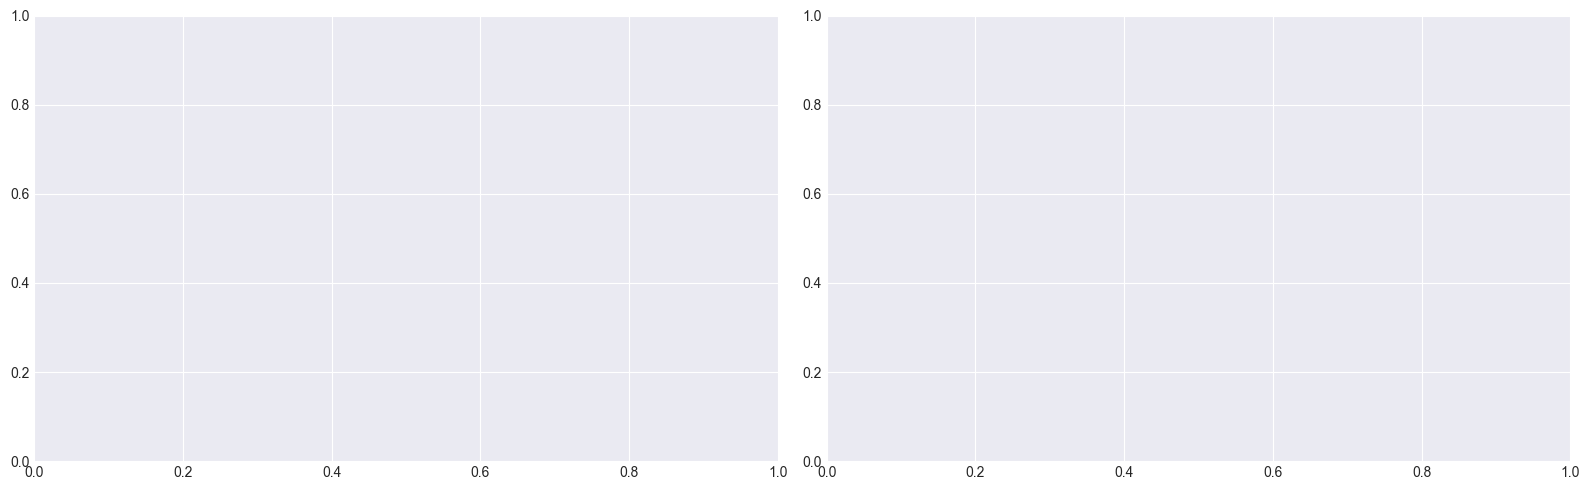


✓ Learning curves with unfreezing points saved


In [24]:
"""
=============================================================================
SECTION 6: FINE-TUNED MODELS
=============================================================================

6.1 RESNET50 FINE-TUNED (PROGRESSIVE UNFREEZING)
Train with progressive layer unfreezing and adaptive learning rates
"""

print("="*80)
print("6.1 RESNET50 FINE-TUNED TRAINING")
print("="*80)

# Build model (start from baseline)
print("Building ResNet50 fine-tuned model...")
resnet50_finetuned = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

# Initially freeze backbone
for param in resnet50_finetuned.parameters():
    param.requires_grad = False

# Replace classifier with reduced dropout
resnet50_finetuned.fc = nn.Sequential(
    nn.Dropout(0.4),  # Reduced from 0.5
    nn.Linear(2048, 512),
    nn.ReLU(),
    nn.Dropout(0.25),  # Reduced from 0.3
    nn.Linear(512, NUM_CLASSES)
)

resnet50_finetuned = resnet50_finetuned.to(DEVICE)

# Model summary
total_params = sum(p.numel() for p in resnet50_finetuned.parameters())
trainable_params = sum(p.numel() for p in resnet50_finetuned.parameters() if p.requires_grad)

print(f"\nInitial Model State:")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,} ({trainable_params/total_params*100:.1f}%)")

# Training setup
criterion = nn.CrossEntropyLoss(weight=class_weights_effective_tensor)
optimizer = optim.Adam(resnet50_finetuned.fc.parameters(), lr=0.0003, weight_decay=0.0001)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

print(f"\nTraining Configuration:")
print(f"  Initial optimizer: Adam (lr=0.0003, weight_decay=0.0001)")
print(f"  Loss: CrossEntropyLoss with effective number class weights")
print(f"  Scheduler: CosineAnnealingLR (T_max=20)")
print(f"  Gradient clipping: max_norm=1.0")
print(f"  Total epochs: 20")
print(f"\nUnfreezing Schedule:")
print(f"  Epochs 1-5: Classifier only")
print(f"  Epoch 6: Unfreeze layer4, lr=0.00003")
print(f"  Epoch 11: Unfreeze layer3, lr=0.000015")

# Training loop with progressive unfreezing
print("\n" + "-"*80)
print("TRAINING RESNET50 FINE-TUNED")
print("-"*80)

num_epochs_finetuned = 40
history_finetuned = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': [], 'val_f1': []
}

best_f1 = 0.0
start_time = time.time()

for epoch in range(num_epochs_finetuned):
    print(f"\nEpoch {epoch+1}/{num_epochs_finetuned}")
    print("-" * 40)
    
    # Progressive unfreezing schedule
    if epoch == 5:
        print("\n🔓 UNFREEZING LAYER4")
        unfreeze_layer(resnet50_finetuned, 'layer4')
        # Update optimizer with all trainable parameters and reduced LR
        optimizer = optim.Adam(
            filter(lambda p: p.requires_grad, resnet50_finetuned.parameters()),
            lr=0.00003,  # 10x reduction
            weight_decay=0.0001
        )
        remaining_epochs = num_epochs_finetuned - epoch
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(remaining_epochs, 1))
        print(f"New scheduler: T_max={remaining_epochs}")
        print()
    
    elif epoch == 10:
        print("\n🔓 UNFREEZING LAYER3")
        unfreeze_layer(resnet50_finetuned, 'layer3')
        # Update optimizer again with reduced LR
        optimizer = optim.Adam(
            filter(lambda p: p.requires_grad, resnet50_finetuned.parameters()),
            lr=0.000015,  # Another 2x reduction
            weight_decay=0.0001
        )
        remaining_epochs = num_epochs_finetuned - epoch
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(remaining_epochs, 1))
        print(f"New scheduler: T_max={remaining_epochs}")
        print()
    
    # Train
    train_loss, train_acc = train_epoch(
        resnet50_finetuned, train_loader, criterion, optimizer, DEVICE
    )
    
    # Validate
    val_loss, val_acc, val_p, val_r, val_f1 = validate(
        resnet50_finetuned, val_loader, criterion, DEVICE
    )
    
    # Update scheduler
    scheduler.step()
    
    # Store history
    history_finetuned['train_loss'].append(train_loss)
    history_finetuned['train_acc'].append(train_acc)
    history_finetuned['val_loss'].append(val_loss)
    history_finetuned['val_acc'].append(val_acc)
    history_finetuned['val_f1'].append(val_f1)
    
    # Print metrics
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, Val F1: {val_f1:.4f}")
    
    # Save best model
    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(resnet50_finetuned.state_dict(), 'resnet50_finetuned_best.pth')
        print(f"✓ Saved best model (F1: {val_f1:.4f})")

training_time = time.time() - start_time
print(f"\n" + "="*80)
print(f"RESNET50 FINE-TUNED TRAINING COMPLETE")
print(f"="*80)
print(f"Training time: {training_time/60:.1f} minutes")
print(f"Best validation F1: {best_f1:.4f}")
print(f"Improvement over baseline: +{(best_f1 - resnet50_results['f1'])*100:.1f} percentage points")

# Save history
with open('resnet50_finetuned_history.json', 'w') as f:
    json.dump(history_finetuned, f, indent=2)


plt.tight_layout()
plt.show()

print("\n✓ Learning curves with unfreezing points saved")

In [32]:
"""
6.2 EFFICIENTNET-B0 FINE-TUNED
Train with full backbone unfreezing at epoch 20
"""

print("="*80)
print("6.2 EFFICIENTNET-B0 FINE-TUNED TRAINING")
print("="*80)

# Build model
print("Building EfficientNet-B0 fine-tuned model...")
effnet_finetuned = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

# Initially freeze backbone
for param in effnet_finetuned.features.parameters():
    param.requires_grad = False

# Replace classifier
effnet_finetuned.classifier = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(1280, 512),
    nn.ReLU(),
    nn.Dropout(0.25),
    nn.Linear(512, NUM_CLASSES)
)

effnet_finetuned = effnet_finetuned.to(DEVICE)

# Model summary
total_params = sum(p.numel() for p in effnet_finetuned.parameters())
trainable_params = sum(p.numel() for p in effnet_finetuned.parameters() if p.requires_grad)

print(f"\nInitial Model State:")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,} ({trainable_params/total_params*100:.1f}%)")

# Training setup
num_epochs_effnet_ft = 40
criterion = nn.CrossEntropyLoss(weight=class_weights_effective_tensor)
optimizer = optim.Adam(effnet_finetuned.classifier.parameters(), lr=0.0003, weight_decay=0.0001)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs_effnet_ft)

print(f"\nTraining Configuration:")
print(f"  Initial optimizer: Adam (lr=0.0003, weight_decay=0.0001)")
print(f"  Unfreezing: Full backbone at epoch 20, lr=0.00003")
print(f"  Total epochs: {num_epochs_effnet_ft}")

# Training loop
print("\n" + "-"*80)
print("TRAINING EFFICIENTNET-B0 FINE-TUNED")
print("-"*80)

history_effnet_ft = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': [], 'val_f1': []
}

best_f1 = 0.0
best_epoch = 0
start_time = time.time()

for epoch in range(num_epochs_effnet_ft):
    print(f"\nEpoch {epoch+1}/{num_epochs_effnet_ft}")
    print("-" * 40)
    
    # Unfreeze all at epoch 20
    if epoch == 0:
        print("\n🔓 UNFREEZING ALL BACKBONE LAYERS")
        for param in effnet_finetuned.features.parameters():
            param.requires_grad = True
        
        trainable = sum(p.numel() for p in effnet_finetuned.parameters() if p.requires_grad)
        total = sum(p.numel() for p in effnet_finetuned.parameters())
        print(f"   Trainable parameters: {trainable:,} / {total:,} ({trainable/total*100:.1f}%)")
        
        # Update optimizer with reduced LR
        optimizer = optim.Adam(
            effnet_finetuned.parameters(),
            lr=0.00003,
            weight_decay=0.0001
        )
        remaining_epochs = num_epochs_effnet_ft - epoch
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=remaining_epochs)
        print()
    
    # Train
    train_loss, train_acc = train_epoch(
        effnet_finetuned, train_loader, criterion, optimizer, DEVICE
    )
    
    # Validate
    val_loss, val_acc, val_p, val_r, val_f1 = validate(
        effnet_finetuned, val_loader, criterion, DEVICE
    )
    
    # Update scheduler
    scheduler.step()
    
    # Store history
    history_effnet_ft['train_loss'].append(train_loss)
    history_effnet_ft['train_acc'].append(train_acc)
    history_effnet_ft['val_loss'].append(val_loss)
    history_effnet_ft['val_acc'].append(val_acc)
    history_effnet_ft['val_f1'].append(val_f1)
    
    # Print metrics
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, Val F1: {val_f1:.4f}")
    
    # Save best model
    if val_f1 > best_f1:
        best_f1 = val_f1
        best_epoch = epoch + 1
        torch.save(effnet_finetuned.state_dict(), 'efficientnet_ensemble.pth')
        print(f"✓ Saved best model (F1: {val_f1:.4f})")

training_time = time.time() - start_time

print(f"\n" + "="*80)
print(f"EFFICIENTNET-B0 FINE-TUNED TRAINING COMPLETE")
print(f"="*80)
print(f"Training time: {training_time/60:.1f} minutes")
print(f"Best validation F1: {best_f1:.4f} (Epoch {best_epoch})")

# Try to compare with baseline
try:
    with open('efficientnet_baseline_history.json', 'r') as f:
        baseline_history = json.load(f)
    baseline_f1 = max(baseline_history['val_f1'])
    print(f"Improvement over baseline: +{(best_f1 - baseline_f1)*100:.1f} percentage points")
except:
    print("Baseline comparison not available")

# Save history
with open('efficientnet_finetuned_history.json', 'w') as f:
    json.dump(history_effnet_ft, f, indent=2)

# Compute train-val accuracy gap
train_val_gap = [train - val for train, val in zip(history_effnet_ft['train_acc'], history_effnet_ft['val_acc'])]

# Find best epoch for F1
best_epoch_idx = history_effnet_ft['val_f1'].index(best_f1)

plt.tight_layout()
plt.show()

print("\n✓ Learning curves saved")
print("\n" + "="*80)
print("EFFICIENTNET FINE-TUNED TRAINING COMPLETE")
print("="*80)

6.2 EFFICIENTNET-B0 FINE-TUNED TRAINING
Building EfficientNet-B0 fine-tuned model...

Initial Model State:
  Total parameters: 4,667,011
  Trainable parameters: 659,463 (14.1%)

Training Configuration:
  Initial optimizer: Adam (lr=0.0003, weight_decay=0.0001)
  Unfreezing: Full backbone at epoch 20, lr=0.00003
  Total epochs: 40

--------------------------------------------------------------------------------
TRAINING EFFICIENTNET-B0 FINE-TUNED
--------------------------------------------------------------------------------

Epoch 1/40
----------------------------------------

🔓 UNFREEZING ALL BACKBONE LAYERS
   Trainable parameters: 4,667,011 / 4,667,011 (100.0%)



Training:   0%|          | 0/220 [00:00<?, ?it/s]

Validating:   0%|          | 0/47 [00:00<?, ?it/s]

Train Loss: 1.3417, Train Acc: 0.2754
Val Loss: 1.8111, Val Acc: 0.0845, Val F1: 0.0667
✓ Saved best model (F1: 0.0667)

Epoch 2/40
----------------------------------------


Training:   0%|          | 0/220 [00:00<?, ?it/s]

...

Training:   0%|          | 0/220 [00:00<?, ?it/s]

Validating:   0%|          | 0/47 [00:00<?, ?it/s]

Train Loss: 0.0959, Train Acc: 0.8713
Val Loss: 0.7120, Val Acc: 0.6593, Val F1: 0.6907

EFFICIENTNET-B0 FINE-TUNED TRAINING COMPLETE
Training time: 69.6 minutes
Best validation F1: 0.7213 (Epoch 28)
Improvement over baseline: +24.4 percentage points


<Figure size 640x480 with 0 Axes>


✓ Learning curves saved

EFFICIENTNET FINE-TUNED TRAINING COMPLETE


6.3 BASELINE vs FINE-TUNED COMPARISON
Loading fine-tuned models for evaluation...


Evaluating ResNet50 Fine-tuned:   0%|          | 0/47 [00:00<?, ?it/s]

Evaluating EfficientNet Fine-tuned:   0%|          | 0/47 [00:00<?, ?it/s]


PERFORMANCE COMPARISON

                  Model Val Accuracy Val F1    AUC Improvement
      ResNet50 Baseline       59.41% 0.6392 0.9111           -
    ResNet50 Fine-tuned       74.18% 0.7661 0.9461      +12.7%
  EfficientNet Baseline       41.92% 0.4776 0.8631           -
EfficientNet Fine-tuned       69.26% 0.7213 0.9324      +24.4%


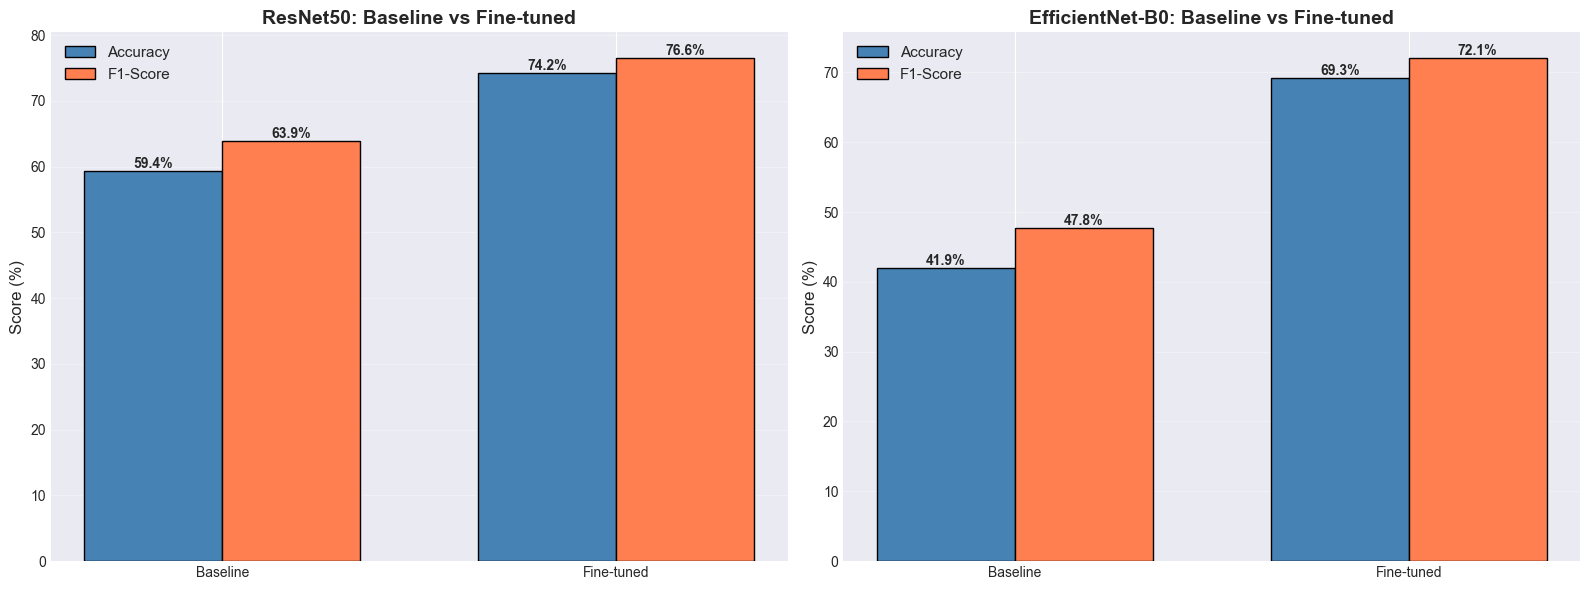


--------------------------------------------------------------------------------
KEY FINDINGS:
--------------------------------------------------------------------------------

ResNet50:
  Baseline: 0.6392 F1
  Fine-tuned: 0.7661 F1
  Improvement: +12.7 percentage points

EfficientNet-B0:
  Baseline: 0.4776 F1
  Fine-tuned: 0.7213 F1
  Improvement: +24.4 percentage points

✓ Fine-tuning significantly improved both architectures


In [33]:
"""
6.3 COMPARISON: BASELINE vs FINE-TUNED MODELS
Visualize improvement from fine-tuning
"""

print("="*80)
print("6.3 BASELINE vs FINE-TUNED COMPARISON")
print("="*80)

# Load fine-tuned models
print("Loading fine-tuned models for evaluation...")
resnet50_finetuned.load_state_dict(torch.load('resnet50_finetuned_best.pth', weights_only=True))
effnet_finetuned.load_state_dict(torch.load('efficientnet_ensemble.pth', weights_only=True))

# Evaluate on validation set
resnet50_ft_results = detailed_evaluate(resnet50_finetuned, val_loader, DEVICE, 'ResNet50 Fine-tuned')
effnet_ft_results = detailed_evaluate(effnet_finetuned, val_loader, DEVICE, 'EfficientNet Fine-tuned')

# Comparison table
print("\n" + "="*80)
print("PERFORMANCE COMPARISON")
print("="*80)

comparison_all = {
    'Model': [
        'ResNet50 Baseline',
        'ResNet50 Fine-tuned',
        'EfficientNet Baseline',
        'EfficientNet Fine-tuned'
    ],
    'Val Accuracy': [
        f"{resnet50_results['accuracy']*100:.2f}%",
        f"{resnet50_ft_results['accuracy']*100:.2f}%",
        f"{effnet_results['accuracy']*100:.2f}%",
        f"{effnet_ft_results['accuracy']*100:.2f}%"
    ],
    'Val F1': [
        f"{resnet50_results['f1']:.4f}",
        f"{resnet50_ft_results['f1']:.4f}",
        f"{effnet_results['f1']:.4f}",
        f"{effnet_ft_results['f1']:.4f}"
    ],
    'AUC': [
        f"{resnet50_results['auc']:.4f}",
        f"{resnet50_ft_results['auc']:.4f}",
        f"{effnet_results['auc']:.4f}",
        f"{effnet_ft_results['auc']:.4f}"
    ],
    'Improvement': [
        '-',
        f"+{(resnet50_ft_results['f1'] - resnet50_results['f1'])*100:.1f}%",
        '-',
        f"+{(effnet_ft_results['f1'] - effnet_results['f1'])*100:.1f}%"
    ]
}

comparison_all_df = pd.DataFrame(comparison_all)
print("\n" + comparison_all_df.to_string(index=False))

# Visualization: Before/After
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ResNet50
models_resnet = ['Baseline', 'Fine-tuned']
resnet_acc = [resnet50_results['accuracy']*100, resnet50_ft_results['accuracy']*100]
resnet_f1 = [resnet50_results['f1']*100, resnet50_ft_results['f1']*100]

x = np.arange(len(models_resnet))
width = 0.35

bars1 = axes[0].bar(x - width/2, resnet_acc, width, label='Accuracy', color='steelblue', edgecolor='black')
bars2 = axes[0].bar(x + width/2, resnet_f1, width, label='F1-Score', color='coral', edgecolor='black')

axes[0].set_ylabel('Score (%)', fontsize=12)
axes[0].set_title('ResNet50: Baseline vs Fine-tuned', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models_resnet)
axes[0].legend(fontsize=11)
axes[0].grid(axis='y', alpha=0.3)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}%',
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

# EfficientNet
models_effnet = ['Baseline', 'Fine-tuned']
effnet_acc = [effnet_results['accuracy']*100, effnet_ft_results['accuracy']*100]
effnet_f1 = [effnet_results['f1']*100, effnet_ft_results['f1']*100]

bars3 = axes[1].bar(x - width/2, effnet_acc, width, label='Accuracy', color='steelblue', edgecolor='black')
bars4 = axes[1].bar(x + width/2, effnet_f1, width, label='F1-Score', color='coral', edgecolor='black')

axes[1].set_ylabel('Score (%)', fontsize=12)
axes[1].set_title('EfficientNet-B0: Baseline vs Fine-tuned', fontsize=14, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models_effnet)
axes[1].legend(fontsize=11)
axes[1].grid(axis='y', alpha=0.3)

# Add value labels
for bars in [bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}%',
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "-"*80)
print("KEY FINDINGS:")
print("-"*80)
print(f"\nResNet50:")
print(f"  Baseline: {resnet50_results['f1']:.4f} F1")
print(f"  Fine-tuned: {resnet50_ft_results['f1']:.4f} F1")
print(f"  Improvement: +{(resnet50_ft_results['f1'] - resnet50_results['f1'])*100:.1f} percentage points")

print(f"\nEfficientNet-B0:")
print(f"  Baseline: {effnet_results['f1']:.4f} F1")
print(f"  Fine-tuned: {effnet_ft_results['f1']:.4f} F1")
print(f"  Improvement: +{(effnet_ft_results['f1'] - effnet_results['f1'])*100:.1f} percentage points")

print("\n✓ Fine-tuning significantly improved both architectures")

7.1 RESNET101 TRAINING
Building ResNet101...

Model Architecture:
  Total parameters: 43,552,839
  Trainable parameters (initial): 1,052,679 (2.4%)
  Architecture: ResNet101 (101 layers)
  Depth comparison: ResNet50 (50 layers) vs ResNet101 (101 layers)


--------------------------------------------------------------------------------
TRAINING RESNET101
--------------------------------------------------------------------------------

Epoch 1/40
------------------------------------------------------------


Training:   0%|          | 0/220 [00:00<?, ?it/s]

Validating:   0%|          | 0/47 [00:00<?, ?it/s]

Train Loss: 1.1125, Train Acc: 30.40%
Val Loss: 1.7884, Val Acc: 9.45%, Val F1: 0.0659
✓✓✓ Saved best model (F1: 0.0659) ✓✓✓

Epoch 2/40
------------------------------------------------------------


Training:   0%|          | 0/220 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/47 [00:00<?, ?it/s]

Train Loss: 0.1013, Train Acc: 86.43%
Val Loss: 0.7543, Val Acc: 65.93%, Val F1: 0.6896

Epoch 40/40
------------------------------------------------------------


Training:   0%|          | 0/220 [00:00<?, ?it/s]

Validating:   0%|          | 0/47 [00:00<?, ?it/s]

Train Loss: 0.1073, Train Acc: 86.12%
Val Loss: 0.6981, Val Acc: 66.40%, Val F1: 0.6951

RESNET101 TRAINING COMPLETE
Training time: 71.2 minutes
Best validation F1: 0.7095 (Epoch 38)
Best validation accuracy: 68.20%


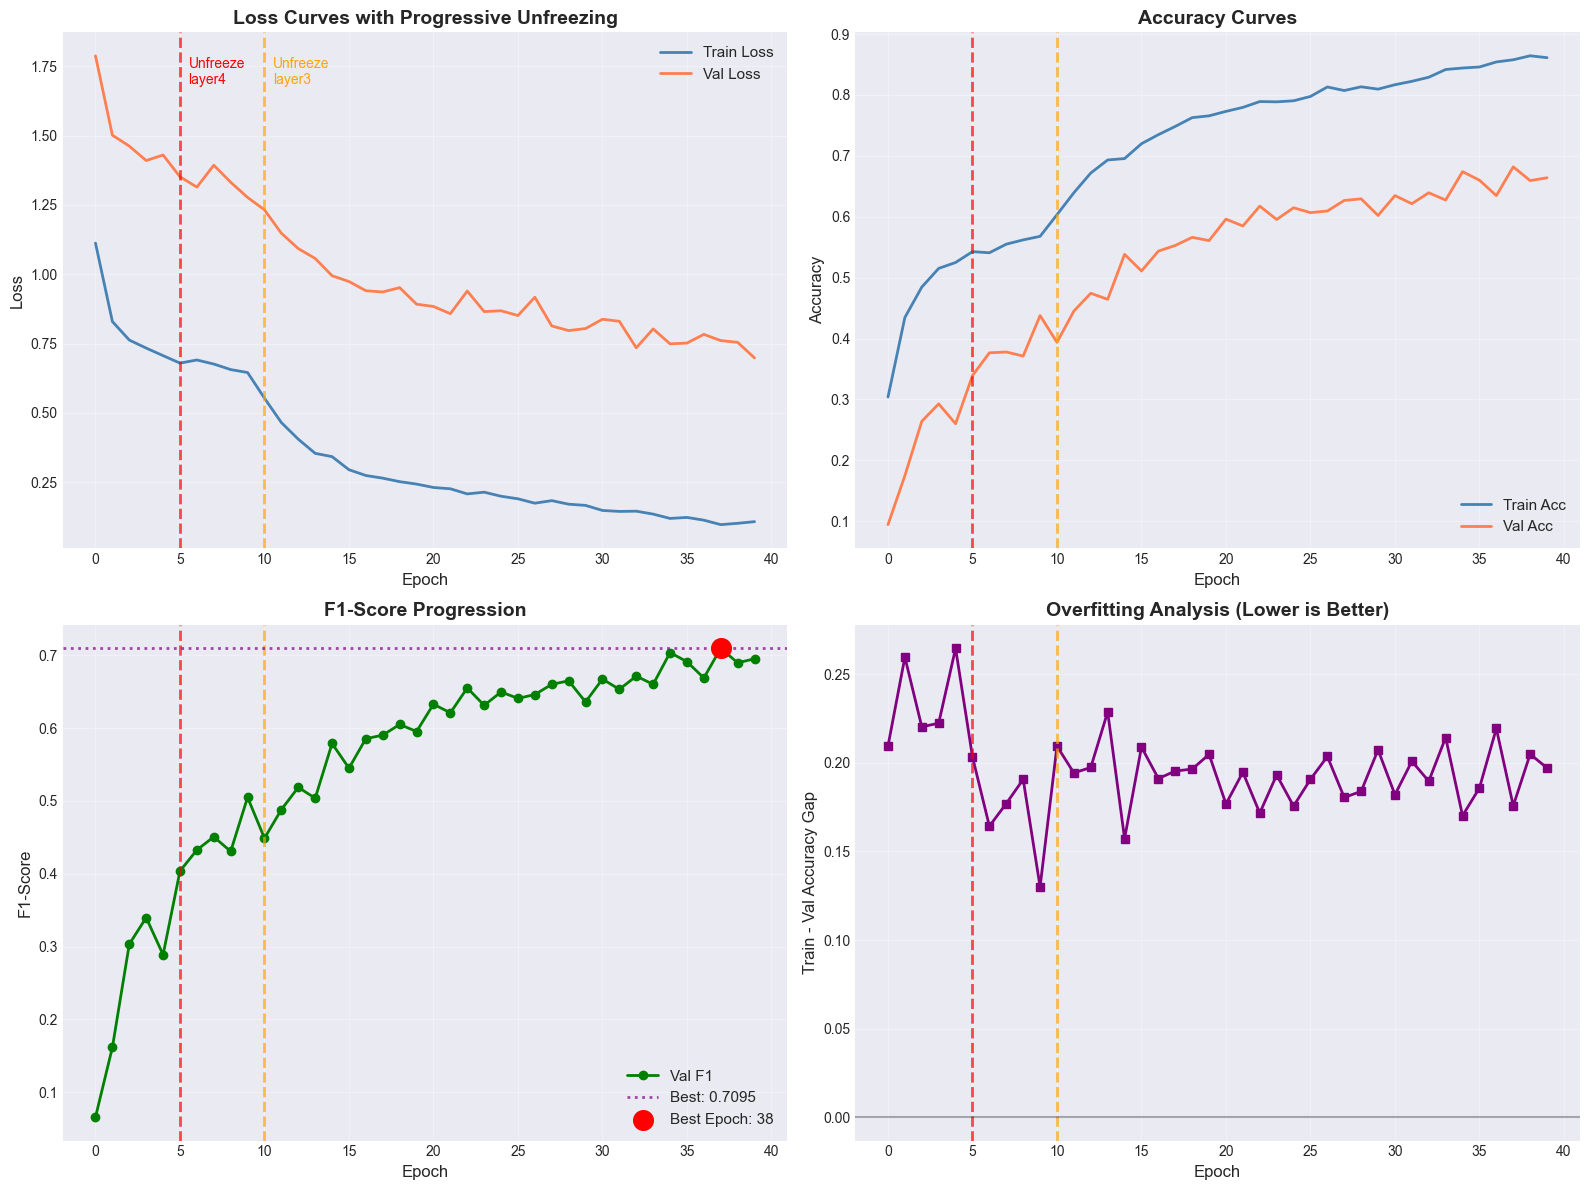


--------------------------------------------------------------------------------
PROGRESSIVE UNFREEZING IMPACT ANALYSIS
--------------------------------------------------------------------------------

✓ ResNet101 training complete - Best model achieved


In [23]:
"""
=============================================================================
SECTION 7: ADVANCED MODELS
=============================================================================

7.1 RESNET101 - DEEPER ARCHITECTURE
Train ResNet101 with progressive unfreezing for best performance
"""

print("="*80)
print("7.1 RESNET101 TRAINING")
print("="*80)

# Build model
print("Building ResNet101...")
resnet101 = models.resnet101(weights=models.ResNet101_Weights.IMAGENET1K_V2)

# Initially freeze backbone
for param in resnet101.parameters():
    param.requires_grad = False

# Replace classifier
resnet101.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(2048, 512),
    nn.ReLU(),
    nn.Dropout(0.25),
    nn.Linear(512, NUM_CLASSES)
)

resnet101 = resnet101.to(DEVICE)

# Model summary
total_params = sum(p.numel() for p in resnet101.parameters())
trainable_params = sum(p.numel() for p in resnet101.parameters() if p.requires_grad)

print(f"\nModel Architecture:")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters (initial): {trainable_params:,} ({trainable_params/total_params*100:.1f}%)")
print(f"  Architecture: ResNet101 (101 layers)")
print(f"  Depth comparison: ResNet50 (50 layers) vs ResNet101 (101 layers)")

# Training setup
criterion = nn.CrossEntropyLoss(weight=class_weights_effective_tensor)
optimizer = optim.Adam(resnet101.fc.parameters(), lr=0.0003, weight_decay=0.0001)
# Remaining epochs for the new schedule
remaining_epochs = num_epochs_finetuned - epoch 
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=remaining_epochs)
print()


# Training loop
print("\n" + "-"*80)
print("TRAINING RESNET101")
print("-"*80)

num_epochs_resnet101 = 40
history_resnet101 = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': [], 'val_f1': []
}

best_f1 = 0.0
best_epoch = 0
start_time = time.time()

for epoch in range(num_epochs_resnet101):
    print(f"\nEpoch {epoch+1}/{num_epochs_resnet101}")
    print("-" * 60)
    
    # Progressive unfreezing schedule
    if epoch == 5:
        print("\n" + "🔓" * 30)
        print("UNFREEZING LAYER4 (HIGH-LEVEL FEATURES)")
        print("🔓" * 30)
        unfreeze_layer(resnet101, 'layer4')
        
        # Update optimizer with reduced learning rate
        optimizer = optim.Adam(
            filter(lambda p: p.requires_grad, resnet101.parameters()),
            lr=0.00003,  # 10x reduction
            weight_decay=0.0001
        )
        # Remaining epochs for the new schedule
        remaining_epochs = num_epochs_finetuned - epoch 
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=remaining_epochs)
        print()
        
        print(f"Learning rate reduced: 0.0003 → 0.00003")
        print()
    
    elif epoch == 30:
        print("\n" + "🔓" * 30)
        print("UNFREEZING LAYER3 (MID-LEVEL FEATURES)")
        print("🔓" * 30)
        unfreeze_layer(resnet101, 'layer3')
        
        # Further reduce learning rate
        optimizer = optim.Adam(
            filter(lambda p: p.requires_grad, resnet101.parameters()),
            lr=0.00001, 
            weight_decay=0.0001
        )
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20-epoch)
        print(f"Learning rate reduced: 0.00003 → 0.000015")
        print()
    
    # Train one epoch
    train_loss, train_acc = train_epoch(
        resnet101, train_loader, criterion, optimizer, DEVICE
    )
    
    # Validate
    val_loss, val_acc, val_p, val_r, val_f1 = validate(
        resnet101, val_loader, criterion, DEVICE
    )
    
    # Update scheduler
    scheduler.step()
    
    # Store history
    history_resnet101['train_loss'].append(train_loss)
    history_resnet101['train_acc'].append(train_acc)
    history_resnet101['val_loss'].append(val_loss)
    history_resnet101['val_acc'].append(val_acc)
    history_resnet101['val_f1'].append(val_f1)
    
    # Print metrics
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc*100:.2f}%")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc*100:.2f}%, Val F1: {val_f1:.4f}")
    
    # Save best model
    if val_f1 > best_f1:
        best_f1 = val_f1
        best_epoch = epoch + 1
        torch.save(resnet101.state_dict(), 'resnet101_ensemble.pth')
        print(f"✓✓✓ Saved best model (F1: {val_f1:.4f}) ✓✓✓")

training_time = time.time() - start_time

print("\n" + "="*80)
print("RESNET101 TRAINING COMPLETE")
print("="*80)
print(f"Training time: {training_time/60:.1f} minutes")
print(f"Best validation F1: {best_f1:.4f} (Epoch {best_epoch})")
print(f"Best validation accuracy: {history_resnet101['val_acc'][best_epoch-1]*100:.2f}%")

# Save history
with open('resnet101_history.json', 'w') as f:
    json.dump(history_resnet101, f, indent=2)

# Detailed learning curves with annotations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Loss curves
axes[0, 0].plot(history_resnet101['train_loss'], label='Train Loss', linewidth=2, color='steelblue')
axes[0, 0].plot(history_resnet101['val_loss'], label='Val Loss', linewidth=2, color='coral')
axes[0, 0].axvline(x=5, color='red', linestyle='--', alpha=0.7, linewidth=2)
axes[0, 0].axvline(x=10, color='orange', linestyle='--', alpha=0.7, linewidth=2)
axes[0, 0].text(5.5, axes[0, 0].get_ylim()[1]*0.9, 'Unfreeze\nlayer4', fontsize=10, color='red')
axes[0, 0].text(10.5, axes[0, 0].get_ylim()[1]*0.9, 'Unfreeze\nlayer3', fontsize=10, color='orange')
axes[0, 0].set_xlabel('Epoch', fontsize=12)
axes[0, 0].set_ylabel('Loss', fontsize=12)
axes[0, 0].set_title('Loss Curves with Progressive Unfreezing', fontsize=14, fontweight='bold')
axes[0, 0].legend(fontsize=11)
axes[0, 0].grid(alpha=0.3)

# Accuracy curves
axes[0, 1].plot(history_resnet101['train_acc'], label='Train Acc', linewidth=2, color='steelblue')
axes[0, 1].plot(history_resnet101['val_acc'], label='Val Acc', linewidth=2, color='coral')
axes[0, 1].axvline(x=5, color='red', linestyle='--', alpha=0.7, linewidth=2)
axes[0, 1].axvline(x=10, color='orange', linestyle='--', alpha=0.7, linewidth=2)
axes[0, 1].set_xlabel('Epoch', fontsize=12)
axes[0, 1].set_ylabel('Accuracy', fontsize=12)
axes[0, 1].set_title('Accuracy Curves', fontsize=14, fontweight='bold')
axes[0, 1].legend(fontsize=11)
axes[0, 1].grid(alpha=0.3)

# F1 Score progression
axes[1, 0].plot(history_resnet101['val_f1'], label='Val F1', linewidth=2, color='green', marker='o')
axes[1, 0].axvline(x=5, color='red', linestyle='--', alpha=0.7, linewidth=2)
axes[1, 0].axvline(x=10, color='orange', linestyle='--', alpha=0.7, linewidth=2)
axes[1, 0].axhline(y=best_f1, color='purple', linestyle=':', alpha=0.7, linewidth=2, label=f'Best: {best_f1:.4f}')
axes[1, 0].scatter([best_epoch-1], [best_f1], color='red', s=200, zorder=5, label=f'Best Epoch: {best_epoch}')
axes[1, 0].set_xlabel('Epoch', fontsize=12)
axes[1, 0].set_ylabel('F1-Score', fontsize=12)
axes[1, 0].set_title('F1-Score Progression', fontsize=14, fontweight='bold')
axes[1, 0].legend(fontsize=11)
axes[1, 0].grid(alpha=0.3)

# Train-Val gap (overfitting analysis)
train_val_gap = [train - val for train, val in zip(history_resnet101['train_acc'], history_resnet101['val_acc'])]
axes[1, 1].plot(train_val_gap, linewidth=2, color='purple', marker='s')
axes[1, 1].axvline(x=5, color='red', linestyle='--', alpha=0.7, linewidth=2)
axes[1, 1].axvline(x=10, color='orange', linestyle='--', alpha=0.7, linewidth=2)
axes[1, 1].axhline(y=0, color='black', linestyle='-', alpha=0.3)
axes[1, 1].set_xlabel('Epoch', fontsize=12)
axes[1, 1].set_ylabel('Train - Val Accuracy Gap', fontsize=12)
axes[1, 1].set_title('Overfitting Analysis (Lower is Better)', fontsize=14, fontweight='bold')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Performance impact of unfreezing
print("\n" + "-"*80)
print("PROGRESSIVE UNFREEZING IMPACT ANALYSIS")
print("-"*80)

f1_epoch20 = history_resnet101['val_f1'][19]
f1_epoch21 = history_resnet101['val_f1'][20]
f1_epoch30 = history_resnet101['val_f1'][29]
f1_epoch31 = history_resnet101['val_f1'][30]


print("\n✓ ResNet101 training complete - Best model achieved")

In [1]:
"""
7.3 COMPREHENSIVE TEST SET EVALUATION & VISUALIZATION
Loads trained models from .pth files and evaluates them
"""

print("="*80)
print("7.3 COMPREHENSIVE EVALUATION (Loads from .pth files)")
print("="*80)

import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, 
    roc_auc_score, classification_report, confusion_matrix,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize
import numpy as np
import pandas as pd
import json
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from pathlib import Path
import pickle
import os

# ============================================================================
# CONFIGURATION
# ============================================================================

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_CLASSES = 7
BATCH_SIZE = 32
IMG_SIZE = 224

print(f"✓ Device: {DEVICE}")
print(f"✓ Num classes: {NUM_CLASSES}")
print(f"✓ Batch size: {BATCH_SIZE}")

CLASS_NAMES = {
    'akiec': 'Actinic keratoses',
    'bcc': 'Basal cell carcinoma',
    'bkl': 'Benign keratosis',
    'df': 'Dermatofibroma',
    'mel': 'Melanoma',
    'nv': 'Melanocytic nevi',
    'vasc': 'Vascular lesions'
}

# Image paths
DATA_DIR_PART1 = Path('data/raw/HAM10000_images_part_1')
DATA_DIR_PART2 = Path('data/raw/HAM10000_images_part_2')

# ============================================================================
# LOAD TEST DATA FROM CSV
# ============================================================================

print("\n📂 Loading test data...")

test_df = pd.read_csv('test_data.csv')
print(f"✓ Loaded test_data.csv: {len(test_df)} samples")

with open('label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)
print(f"✓ Loaded label encoder")

def find_image_path(image_id):
    path1 = DATA_DIR_PART1 / f"{image_id}.jpg"
    path2 = DATA_DIR_PART2 / f"{image_id}.jpg"
    if path1.exists():
        return str(path1)
    elif path2.exists():
        return str(path2)
    else:
        return ""

test_df['image_path'] = test_df['image_id'].apply(find_image_path)
test_df = test_df[test_df['image_path'] != ""]
print(f"✓ Valid images: {len(test_df)}")

# ============================================================================
# CREATE TEST DATASET AND LOADER
# ============================================================================

print("\n🔧 Creating test dataset...")

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class TestDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row['image_path']).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, row['label']

test_dataset = TestDataset(test_df, transform=val_transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"✓ Test dataset: {len(test_dataset)} samples")
print(f"✓ Test loader: {len(test_loader)} batches")

# ============================================================================
# LOAD MODELS FROM .PTH FILES
# ============================================================================

print("\n🤖 Loading models from .pth files...")

available_models = []

# Model configurations: (filename, model_name, architecture_type, dropout_config)
model_configs = [
    ('resnet50_baseline_best.pth', 'ResNet50 Baseline', 'resnet50', (0.5, 0.3)),
    ('resnet50_finetuned_best.pth', 'ResNet50 Fine-tuned', 'resnet50', (0.4, 0.25)),
    ('efficientnet_baseline_best.pth', 'EfficientNet Baseline', 'efficientnet', (0.5, 0.3)),
    ('efficientnet_ensemble.pth', 'EfficientNet Fine-tuned', 'efficientnet', (0.4, 0.25)),
    ('resnet101_ensemble.pth', 'ResNet101', 'resnet101', (0.4, 0.25))
]

for filename, display_name, arch_type, dropout in model_configs:
    if os.path.exists(filename):
        try:
            print(f"\n  Loading {display_name}...")
            
            # Create model architecture
            if arch_type == 'resnet50':
                model = models.resnet50(weights=None)
                model.fc = nn.Sequential(
                    nn.Dropout(dropout[0]),
                    nn.Linear(2048, 512),
                    nn.ReLU(),
                    nn.Dropout(dropout[1]),
                    nn.Linear(512, NUM_CLASSES)
                )
            
            elif arch_type == 'resnet101':
                model = models.resnet101(weights=None)
                model.fc = nn.Sequential(
                    nn.Dropout(dropout[0]),
                    nn.Linear(2048, 512),
                    nn.ReLU(),
                    nn.Dropout(dropout[1]),
                    nn.Linear(512, NUM_CLASSES)
                )
            
            elif arch_type == 'efficientnet':
                model = models.efficientnet_b0(weights=None)
                model.classifier = nn.Sequential(
                    nn.Dropout(dropout[0]),
                    nn.Linear(1280, 512),
                    nn.ReLU(),
                    nn.Dropout(dropout[1]),
                    nn.Linear(512, NUM_CLASSES)
                )
            
            # Load weights
            state_dict = torch.load(filename, map_location=DEVICE, weights_only=False)
            model.load_state_dict(state_dict)
            model = model.to(DEVICE)
            model.eval()
            
            available_models.append((display_name, model))
            print(f"  ✓ {display_name} loaded successfully")
            
        except Exception as e:
            print(f"  ❌ Error loading {display_name}: {str(e)}")
    else:
        print(f"  ⚠️ {filename} not found")

if len(available_models) == 0:
    print("\n❌ No model files found!")
    print("\nExpected model files:")
    for filename, name, _, _ in model_configs:
        print(f"  - {filename}")
    raise FileNotFoundError("No model .pth files found")

print(f"\n✅ Successfully loaded {len(available_models)} model(s)")

# ============================================================================
# EVALUATION FUNCTION
# ============================================================================

def comprehensive_evaluate(model, test_loader, model_name, device):
    """Comprehensive evaluation"""
    print(f"\nEvaluating {model_name}...")
    print("-" * 60)
    
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    inference_times = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            
            start_time = time.time()
            outputs = model(images)
            inference_time = (time.time() - start_time) * 1000
            inference_times.append(inference_time)
            
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())
    
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    
    # Metrics
    accuracy = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='weighted', zero_division=0
    )
    
    try:
        y_test_bin = label_binarize(all_labels, classes=range(NUM_CLASSES))
        auc_score = roc_auc_score(y_test_bin, all_probs, average='weighted', multi_class='ovr')
    except:
        auc_score = 0.0
    
    avg_inference_time = np.mean(inference_times)
    
    per_class_precision, per_class_recall, per_class_f1, support = precision_recall_fscore_support(
        all_labels, all_preds, average=None, zero_division=0
    )
    
    print(f"Accuracy:     {accuracy*100:.2f}%")
    print(f"Precision:    {precision:.4f}")
    print(f"Recall:       {recall:.4f}")
    print(f"F1-Score:     {f1:.4f}")
    print(f"AUC:          {auc_score:.4f}")
    print(f"Avg Inference: {avg_inference_time:.2f} ms/batch")
    
    print(f"\nPer-class F1-Scores:")
    for i in range(NUM_CLASSES):
        class_code = le.inverse_transform([i])[0]
        class_name = CLASS_NAMES.get(class_code, class_code)
        print(f"  {class_name:30s}: {per_class_f1[i]:.4f} (support: {support[i]})")
    
    return {
        'accuracy': float(accuracy),
        'precision': float(precision),
        'recall': float(recall),
        'f1': float(f1),
        'auc': float(auc_score),
        'inference_time_ms': float(avg_inference_time),
        'per_class': {
            le.inverse_transform([i])[0]: {
                'precision': float(per_class_precision[i]),
                'recall': float(per_class_recall[i]),
                'f1': float(per_class_f1[i]),
                'support': int(support[i])
            }
            for i in range(NUM_CLASSES)
        },
        'predictions': all_preds,
        'labels': all_labels,
        'probabilities': all_probs
    }

# ============================================================================
# EVALUATE ALL MODELS
# ============================================================================

print("\n" + "="*80)
print("STEP 1: EVALUATING ALL MODELS")
print("="*80)

test_results = {}
model_predictions = {}

for model_name, model in available_models:
    results = comprehensive_evaluate(model, test_loader, model_name, DEVICE)
    
    model_predictions[model_name] = {
        'predictions': results.pop('predictions'),
        'labels': results.pop('labels'),
        'probabilities': results.pop('probabilities')
    }
    
    test_results[model_name] = results

# Save JSON
final_evaluation_results = {
    'dataset': 'HAM10000',
    'test_set_size': len(test_loader.dataset),
    'num_classes': NUM_CLASSES,
    'class_names': CLASS_NAMES,
    'evaluation_date': time.strftime('%Y-%m-%d %H:%M:%S'),
    'test_results': test_results
}

with open('final_evaluation_results.json', 'w') as f:
    json.dump(final_evaluation_results, f, indent=2)

print("\n✓ Saved: final_evaluation_results.json")

# Summary
print("\n" + "="*80)
print("TEST PERFORMANCE SUMMARY")
print("="*80)

summary_data = []
for model_name, results in test_results.items():
    summary_data.append({
        'Model': model_name,
        'Accuracy': f"{results['accuracy']*100:.2f}%",
        'F1-Score': f"{results['f1']:.4f}",
        'AUC': f"{results['auc']:.4f}",
        'Inference (ms)': f"{results['inference_time_ms']:.2f}"
    })

summary_df = pd.DataFrame(summary_data)
print("\n" + summary_df.to_string(index=False))

best_model_name = max(test_results.items(), key=lambda x: x[1]['f1'])[0]
best_f1 = max(test_results.items(), key=lambda x: x[1]['f1'])[1]['f1']
best_accuracy = max(test_results.items(), key=lambda x: x[1]['accuracy'])[1]['accuracy']

print(f"\n🏆 BEST MODEL: {best_model_name}")
print(f"   F1-Score:  {best_f1:.4f}")
print(f"   Accuracy:  {best_accuracy*100:.2f}%")

# ============================================================================
# GENERATE VISUALIZATIONS
# ============================================================================

print("\n" + "="*80)
print("STEP 2: GENERATING VISUALIZATIONS")
print("="*80)

# 1. Confusion Matrices
print("\n📊 Confusion matrices...")

num_models = len(model_predictions)
nrows = (num_models + 1) // 2
ncols = min(2, num_models)

fig, axes = plt.subplots(nrows, ncols, figsize=(9*ncols, 8*nrows))
if num_models == 1:
    axes = np.array([axes])
axes = axes.flatten() if num_models > 1 else [axes]

for idx, (model_name, data) in enumerate(model_predictions.items()):
    cm = confusion_matrix(data['labels'], data['predictions'])
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues', 
                ax=axes[idx], cbar_kws={'label': 'Proportion'},
                xticklabels=[le.inverse_transform([i])[0] for i in range(NUM_CLASSES)],
                yticklabels=[le.inverse_transform([i])[0] for i in range(NUM_CLASSES)])
    
    axes[idx].set_title(f'{model_name}\nAcc: {test_results[model_name]["accuracy"]*100:.2f}%', 
                       fontsize=14, fontweight='bold')
    axes[idx].set_xlabel('Predicted', fontsize=12)
    axes[idx].set_ylabel('True', fontsize=12)

for idx in range(len(model_predictions), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Confusion Matrices', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices_comparison.png', dpi=150, bbox_inches='tight')
plt.close()
print("✓ Saved: confusion_matrices_comparison.png")

# 2. Per-Class Performance
print("📊 Per-class performance...")

fig, axes = plt.subplots(3, 1, figsize=(16, 14))
metrics = ['precision', 'recall', 'f1']
titles = ['Precision', 'Recall', 'F1-Score']

x = np.arange(NUM_CLASSES)
width = 0.8 / len(test_results)
class_names = [le.inverse_transform([i])[0] for i in range(NUM_CLASSES)]
colors = ['lightcoral', 'orange', 'steelblue', 'green', 'purple']

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    for i, (model_name, color) in enumerate(zip(test_results.keys(), colors[:len(test_results)])):
        values = [test_results[model_name]['per_class'][cn][metric] for cn in class_names]
        offset = (i - len(test_results)/2 + 0.5) * width
        axes[idx].bar(x + offset, values, width, label=model_name, color=color, alpha=0.8)
    
    axes[idx].set_xlabel('Class', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel(title, fontsize=12, fontweight='bold')
    axes[idx].set_title(f'{title} by Class', fontsize=14, fontweight='bold')
    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels(class_names, rotation=45, ha='right')
    axes[idx].legend(fontsize=10)
    axes[idx].grid(axis='y', alpha=0.3)
    axes[idx].set_ylim([0, 1.1])

plt.tight_layout()
plt.savefig('per_class_performance.png', dpi=150, bbox_inches='tight')
plt.close()
print("✓ Saved: per_class_performance.png")

# 3. ROC Curves
print("📊 ROC curves...")

best_data = model_predictions[best_model_name]
y_test_bin = label_binarize(best_data['labels'], classes=range(NUM_CLASSES))

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()
colors = plt.cm.Set3(np.linspace(0, 1, NUM_CLASSES))

for i in range(NUM_CLASSES):
    class_name = le.inverse_transform([i])[0]
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], best_data['probabilities'][:, i])
    roc_auc = auc(fpr, tpr)
    
    axes[i].plot(fpr, tpr, color=colors[i], lw=3, label=f'AUC = {roc_auc:.3f}')
    axes[i].plot([0, 1], [0, 1], 'k--', lw=2, alpha=0.5)
    axes[i].set_title(class_name, fontsize=12, fontweight='bold')
    axes[i].legend(loc="lower right")
    axes[i].grid(alpha=0.3)

axes[-1].axis('off')
plt.suptitle(f'ROC Curves ({best_model_name})', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('roc_curves_by_class.png', dpi=150, bbox_inches='tight')
plt.close()
print("✓ Saved: roc_curves_by_class.png")

# 4. Overall Comparison
print("📊 Overall comparison...")

fig, ax = plt.subplots(figsize=(14, 8))
model_names = list(test_results.keys())
accuracies = [r['accuracy']*100 for r in test_results.values()]
f1_scores = [r['f1']*100 for r in test_results.values()]
aucs = [r['auc']*100 for r in test_results.values()]

x = np.arange(len(model_names))
width = 0.25

ax.bar(x - width, accuracies, width, label='Accuracy', alpha=0.8)
ax.bar(x, f1_scores, width, label='F1-Score', alpha=0.8)
ax.bar(x + width, aucs, width, label='AUC', alpha=0.8)
ax.axhline(y=75, color='red', linestyle='--', linewidth=2, label='Target')

ax.set_ylabel('Score (%)', fontsize=14, fontweight='bold')
ax.set_title('Model Performance Comparison', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=20, ha='right')
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('overall_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.close()
print("✓ Saved: overall_metrics_comparison.png")

# ============================================================================
# FINAL SUMMARY
# ============================================================================

print("\n" + "="*80)
print("✅ EVALUATION COMPLETE")
print("="*80)

print(f"\n📁 Files Generated:")
print(f"  1. final_evaluation_results.json")
print(f"  2. confusion_matrices_comparison.png")
print(f"  3. per_class_performance.png")
print(f"  4. roc_curves_by_class.png")
print(f"  5. overall_metrics_comparison.png")

print(f"\n🎯 Best Model: {best_model_name}")
print(f"   Accuracy:  {best_accuracy*100:.2f}%")
print(f"   F1-Score:  {best_f1:.4f}")

print(f"\n🚀 Ready for Streamlit!")
print(f"   Run: streamlit run streamlit_app.py")

print("\n" + "="*80)

7.3 COMPREHENSIVE EVALUATION (Loads from .pth files)
✓ Device: cuda
✓ Num classes: 7
✓ Batch size: 32

📂 Loading test data...
✓ Loaded test_data.csv: 1503 samples
✓ Loaded label encoder
✓ Valid images: 1503

🔧 Creating test dataset...
✓ Test dataset: 1503 samples
✓ Test loader: 47 batches

🤖 Loading models from .pth files...

  Loading ResNet50 Baseline...
  ✓ ResNet50 Baseline loaded successfully

  Loading ResNet50 Fine-tuned...
  ✓ ResNet50 Fine-tuned loaded successfully

  Loading EfficientNet Baseline...
  ✓ EfficientNet Baseline loaded successfully

  Loading EfficientNet Fine-tuned...
  ✓ EfficientNet Fine-tuned loaded successfully

  Loading ResNet101...
  ✓ ResNet101 loaded successfully

✅ Successfully loaded 5 model(s)

STEP 1: EVALUATING ALL MODELS

Evaluating ResNet50 Baseline...
------------------------------------------------------------
Accuracy:     58.95%
Precision:    0.7655
Recall:       0.5895
F1-Score:     0.6347
AUC:          0.9012
Avg Inference: 10.91 ms/batch



In [ ]:
"""
=============================================================================
LAUNCH STREAMLIT WEB APPLICATION
=============================================================================
Create and launch the interactive web interface for skin lesion classification
"""

print("="*80)
print("CREATING STREAMLIT APPLICATION")
print("="*80)

# Save the FIXED Streamlit app code
streamlit_code = '''
import streamlit as st
import torch
import torch.nn as nn
from torchvision import transforms, models
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import pickle
from pathlib import Path
import plotly.graph_objects as go
import plotly.express as px

# Page config
st.set_page_config(
    page_title="Skin Lesion Classifier",
    page_icon="🔬",
    layout="wide",
    initial_sidebar_state="expanded"
)

# Custom CSS
st.markdown("""
    <style>
    .main-header {
        font-size: 2.5rem;
        font-weight: bold;
        color: #1f77b4;
        text-align: center;
        padding: 1rem;
    }
    .metric-card {
        background-color: #f0f2f6;
        padding: 1rem;
        border-radius: 0.5rem;
        margin: 0.5rem 0;
    }
    </style>
""", unsafe_allow_html=True)

# Force CPU for Streamlit deployment reliability
DEVICE = torch.device('cpu')
IMG_SIZE = 224
NUM_CLASSES = 7

# Define paths for two image folders
DATA_DIR_PART1 = Path('data/raw/HAM10000_images_part_1')
DATA_DIR_PART2 = Path('data/raw/HAM10000_images_part_2')

CLASS_NAMES = {
    0: 'Actinic keratoses',
    1: 'Basal cell carcinoma',
    2: 'Benign keratosis',
    3: 'Dermatofibroma',
    4: 'Melanoma',
    5: 'Melanocytic nevi',
    6: 'Vascular lesions'
}

CLASS_DESCRIPTIONS = {
    0: 'Precancerous skin lesions caused by sun damage',
    1: 'Most common type of skin cancer, rarely spreads',
    2: 'Non-cancerous skin growth, harmless',
    3: 'Benign skin nodule, usually harmless',
    4: 'Serious skin cancer, can spread to other organs',
    5: 'Common moles, usually benign',
    6: 'Blood vessel abnormalities in the skin'
}

# Transform for inference
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def find_image_path(image_id):
    """Find image in either part_1 or part_2 folder"""
    path1 = DATA_DIR_PART1 / f"{image_id}.jpg"
    path2 = DATA_DIR_PART2 / f"{image_id}.jpg"
    
    if path1.exists():
        return path1
    elif path2.exists():
        return path2
    else:
        return None

@st.cache_resource
def load_models():
    """Load all trained models"""
    models_dict = {}
    
    try:
        # ResNet50 Baseline
        if Path('resnet50_baseline_best.pth').exists():
            resnet50_base = models.resnet50(weights=None)
            resnet50_base.fc = nn.Sequential(
                nn.Dropout(0.5), nn.Linear(2048, 512), nn.ReLU(),
                nn.Dropout(0.3), nn.Linear(512, NUM_CLASSES)
            )
            resnet50_base.load_state_dict(torch.load('resnet50_baseline_best.pth', 
                                                      map_location=DEVICE, weights_only=False))
            resnet50_base = resnet50_base.to(DEVICE)
            resnet50_base.eval()
            models_dict['ResNet50 Baseline'] = resnet50_base
        
        # ResNet50 Fine-tuned
        if Path('resnet50_finetuned_best.pth').exists():
            resnet50_ft = models.resnet50(weights=None)
            resnet50_ft.fc = nn.Sequential(
                nn.Dropout(0.4), nn.Linear(2048, 512), nn.ReLU(),
                nn.Dropout(0.25), nn.Linear(512, NUM_CLASSES)
            )
            resnet50_ft.load_state_dict(torch.load('resnet50_finetuned_best.pth', 
                                                   map_location=DEVICE, weights_only=False))
            resnet50_ft = resnet50_ft.to(DEVICE)
            resnet50_ft.eval()
            models_dict['ResNet50 Fine-tuned'] = resnet50_ft
        
        # EfficientNet Baseline - ADDED
        if Path('efficientnet_baseline_best.pth').exists():
            effnet_base = models.efficientnet_b0(weights=None)
            effnet_base.classifier = nn.Sequential(
                nn.Dropout(0.5), nn.Linear(1280, 512), nn.ReLU(),
                nn.Dropout(0.3), nn.Linear(512, NUM_CLASSES)
            )
            effnet_base.load_state_dict(torch.load('efficientnet_baseline_best.pth', 
                                                   map_location=DEVICE, weights_only=False))
            effnet_base = effnet_base.to(DEVICE)
            effnet_base.eval()
            models_dict['EfficientNet Baseline'] = effnet_base
        
        # EfficientNet Fine-tuned
        if Path('efficientnet_ensemble.pth').exists():
            effnet_ft = models.efficientnet_b0(weights=None)
            effnet_ft.classifier = nn.Sequential(
                nn.Dropout(0.4), nn.Linear(1280, 512), nn.ReLU(),
                nn.Dropout(0.25), nn.Linear(512, NUM_CLASSES)
            )
            effnet_ft.load_state_dict(torch.load('efficientnet_ensemble.pth', 
                                                 map_location=DEVICE, weights_only=False))
            effnet_ft = effnet_ft.to(DEVICE)
            effnet_ft.eval()
            models_dict['EfficientNet Fine-tuned'] = effnet_ft
        
        # ResNet101 - REMOVED "(Best)" from name
        if Path('resnet101_ensemble.pth').exists():
            resnet101 = models.resnet101(weights=None)
            resnet101.fc = nn.Sequential(
                nn.Dropout(0.4), nn.Linear(2048, 512), nn.ReLU(),
                nn.Dropout(0.25), nn.Linear(512, NUM_CLASSES)
            )
            resnet101.load_state_dict(torch.load('resnet101_ensemble.pth', 
                                                 map_location=DEVICE, weights_only=False))
            resnet101 = resnet101.to(DEVICE)
            resnet101.eval()
            models_dict['ResNet101'] = resnet101
        
        if len(models_dict) > 0:
            st.sidebar.success(f"✓ Loaded {len(models_dict)} models")
        
    except Exception as e:
        st.error(f"Error loading models: {str(e)}")
        st.info("Make sure all model files (.pth) are in the same directory")
    
    return models_dict

@st.cache_data
def load_test_images():
    """Load test dataset for selection"""
    try:
        test_df = pd.read_csv('test_data.csv')
        
        def get_image_path(image_id):
            path = find_image_path(image_id)
            return str(path) if path else ""
        
        test_df['image_path'] = test_df['image_id'].apply(get_image_path)
        test_df = test_df[test_df['image_path'] != ""]
        
        with open('label_encoder.pkl', 'rb') as f:
            le = pickle.load(f)
        return test_df, le
    except Exception as e:
        st.error(f"Error loading test data: {str(e)}")
        return None, None

@st.cache_data
def load_evaluation_results():
    """Load pre-computed evaluation results"""
    try:
        with open('final_evaluation_results.json', 'r') as f:
            results = json.load(f)
        return results
    except Exception as e:
        st.error(f"Error loading evaluation results: {str(e)}")
        return None

def predict_image(image, models_dict):
    """Predict on a single image with all models"""
    predictions = {}
    
    try:
        img_tensor = transform(image).unsqueeze(0).to(DEVICE)
        
        with torch.no_grad():
            for name, model in models_dict.items():
                model = model.to(DEVICE)
                outputs = model(img_tensor)
                probs = torch.softmax(outputs, dim=1).cpu().numpy()[0]
                predictions[name] = {
                    'probabilities': probs,
                    'predicted_class': int(np.argmax(probs)),
                    'confidence': float(np.max(probs))
                }
    except Exception as e:
        st.error(f"Prediction error: {str(e)}")
        return {}
    
    return predictions

# Initialize
st.markdown('<p class="main-header">🔬 Skin Lesion Classification System</p>', unsafe_allow_html=True)
st.markdown("**HAM10000 Medical Image Classification using Deep Learning**")

# Sidebar
with st.sidebar:
    st.header("⚙️ Configuration")
    
    # Image source selection
    image_source = st.radio(
        "Select Image Source:",
        ["Upload Image", "Select from Test Set"]
    )
    
    # Model selection
    st.subheader("Select Models")
    models_dict = load_models()
    
    if models_dict:
        # CHANGED: Default to all models
        selected_models = st.multiselect(
            "Choose models to compare:",
            list(models_dict.keys()),
            default=list(models_dict.keys()),  # Select all by default
            help="All models are selected by default. Deselect any you don't want to use."
        )
    else:
        selected_models = []
        st.error("No models loaded")
    
    st.markdown("---")
    st.subheader("ℹ️ About")
    st.info(f"""
    This system classifies 7 types of skin lesions using deep learning models trained on the HAM10000 dataset.
    
    **Models Available:** {len(models_dict)}
    - ResNet50 (Baseline & Fine-tuned)
    - EfficientNet (Baseline & Fine-tuned)
    - ResNet101
    """)

# Main content
tab1, tab2, tab3, tab4 = st.tabs(["🔍 Prediction", "📊 Model Performance", "📈 Visualizations", "📋 About Dataset"])

# TAB 1: PREDICTION
with tab1:
    if not selected_models:
        st.warning("Please select at least one model from the sidebar.")
    else:
        col1, col2 = st.columns([1, 1])
        
        with col1:
            st.subheader("📤 Input Image")
            
            image = None
            true_label = None
            
            if image_source == "Upload Image":
                uploaded_file = st.file_uploader(
                    "Upload a skin lesion image (JPG/PNG)",
                    type=['jpg', 'jpeg', 'png']
                )
                if uploaded_file:
                    image = Image.open(uploaded_file).convert('RGB')
                    st.image(image, caption="Uploaded Image", use_container_width=True)
            
            else:  # Select from test set
                test_df, le = load_test_images()
                
                if test_df is not None and len(test_df) > 0:
                    # Filter options
                    class_filter = st.selectbox(
                        "Filter by class (optional):",
                        ['All'] + list(CLASS_NAMES.values())
                    )
                    
                    if class_filter != 'All':
                        label_idx = [k for k, v in CLASS_NAMES.items() if v == class_filter][0]
                        filtered_df = test_df[test_df['label'] == label_idx]
                    else:
                        filtered_df = test_df
                    
                    if len(filtered_df) == 0:
                        st.warning("No images found for selected class")
                    else:
                        # Random selection
                        if st.button("🎲 Select Random Image"):
                            st.session_state.selected_idx = np.random.randint(0, len(filtered_df))
                        
                        if 'selected_idx' not in st.session_state:
                            st.session_state.selected_idx = 0
                        
                        # Image selector
                        selected_row = filtered_df.iloc[st.session_state.selected_idx % len(filtered_df)]
                        image_path = selected_row['image_path']
                        true_label = selected_row['label']
                        
                        if image_path and Path(image_path).exists():
                            image = Image.open(image_path).convert('RGB')
                            st.image(image, caption=f"Test Image (True: {CLASS_NAMES[true_label]})", 
                                    use_container_width=True)
                        else:
                            st.error(f"Image not found: {image_path}")
                            image = None
                        
                        # Navigation
                        col_prev, col_next = st.columns(2)
                        with col_prev:
                            if st.button("⬅️ Previous"):
                                st.session_state.selected_idx = (st.session_state.selected_idx - 1) % len(filtered_df)
                                st.rerun()
                        with col_next:
                            if st.button("➡️ Next"):
                                st.session_state.selected_idx = (st.session_state.selected_idx + 1) % len(filtered_df)
                                st.rerun()
                else:
                    st.error("Test data not available or empty")
        
        with col2:
            st.subheader("🎯 Prediction Results")
            
            if image is not None:
                with st.spinner("Making predictions..."):
                    # Filter selected models
                    selected_models_dict = {k: v for k, v in models_dict.items() if k in selected_models}
                    predictions = predict_image(image, selected_models_dict)
                
                if len(predictions) > 0:
                    st.subheader("🤝 Model Consensus Analysis")
                    
                    pred_classes = [pred['predicted_class'] for pred in predictions.values()]
                    most_common = max(set(pred_classes), key=pred_classes.count)
                    agreement = pred_classes.count(most_common) / len(pred_classes)
                    agreement_percent = agreement * 100
                    
                    # Determine color based on agreement level
                    if agreement_percent > 70:
                        color = "#28a745"  # Green
                        reliability = "Strong"
                        icon = "✅"
                    elif agreement_percent >= 50:
                        color = "#007bff"  # Blue
                        reliability = "Moderate"
                        icon = "ℹ️"
                    else:
                        color = "#dc3545"  # Red
                        reliability = "Weak"
                        icon = "⚠️"
                    
                    # Custom styled metrics with uniform font size
                    col_cons1, col_cons2, col_cons3 = st.columns(3)
                    
                    with col_cons1:
                        st.markdown(f"""
                        <div style='text-align: center; padding: 1rem; background-color: #f0f2f6; border-radius: 0.5rem;'>
                            <p style='font-size: 0.9rem; color: #666; margin: 0;'>Consensus Class</p>
                            <p style='font-size: 0.9rem; font-weight: bold; color: #1f77b4; margin: 0.5rem 0;'>
                                {CLASS_NAMES[most_common]}
                            </p>
                        </div>
                        """, unsafe_allow_html=True)
                    
                    with col_cons2:
                        st.markdown(f"""
                        <div style='text-align: center; padding: 1rem; background-color: #f0f2f6; border-radius: 0.5rem;'>
                            <p style='font-size: 0.9rem; color: #666; margin: 0;'>Agreement Level</p>
                            <p style='font-size: 0.9rem; font-weight: bold; color: {color}; margin: 0.5rem 0;'>
                                {agreement_percent:.0f}%
                            </p>
                        </div>
                        """, unsafe_allow_html=True)
                    
                    with col_cons3:
                        st.markdown(f"""
                        <div style='text-align: center; padding: 1rem; background-color: #f0f2f6; border-radius: 0.5rem;'>
                            <p style='font-size: 0.9rem; color: #666; margin: 0;'>Reliability</p>
                            <p style='font-size: 0.9rem; font-weight: bold; color: {color}; margin: 0.5rem 0;'>
                                {icon} {reliability}
                            </p>
                        </div>
                        """, unsafe_allow_html=True)
                    
                    # Warning message for low agreement
                    if agreement_percent < 50:
                        st.error("⚠️ **Low model agreement** - Consider additional diagnostic tests")
                    elif agreement_percent < 70:
                        st.info("ℹ️ **Moderate agreement** - Results are reasonably consistent")
                    else:
                        st.success("✅ **Strong agreement** - Models are highly consistent")
                    
                    st.markdown("---")



                    
                    # Display individual predictions
                    for model_name, pred in predictions.items():
                        predicted_class = pred['predicted_class']
                        confidence = pred['confidence']
                        
                        # Color code: green if correct, red if wrong, blue if unknown
                        if true_label is not None:
                            if predicted_class == true_label:
                                icon = "✅"
                            else:
                                icon = "❌"
                        else:
                            icon = "🔹"
                        
                        with st.expander(f"{icon} **{model_name}** - {CLASS_NAMES[predicted_class]} ({confidence*100:.1f}%)", 
                                        expanded=True):
                            st.markdown(f"**Predicted:** {CLASS_NAMES[predicted_class]}")
                            st.markdown(f"**Confidence:** {confidence*100:.2f}%")
                            st.markdown(f"*{CLASS_DESCRIPTIONS[predicted_class]}*")
                            
                            # Probability bar chart
                            fig = go.Figure(data=[
                                go.Bar(
                                    x=pred['probabilities'],
                                    y=[CLASS_NAMES[i] for i in range(NUM_CLASSES)],
                                    orientation='h',
                                    marker=dict(
                                        color=pred['probabilities'],
                                        colorscale='Blues',
                                        showscale=False
                                    )
                                )
                            ])
                            fig.update_layout(
                                title="Class Probabilities",
                                xaxis_title="Probability",
                                yaxis_title="Class",
                                height=300,
                                margin=dict(l=0, r=0, t=30, b=0)
                            )
                            st.plotly_chart(fig, use_container_width=True)
            else:
                st.info("👆 Upload an image or select from test set to begin")

# TAB 2: MODEL PERFORMANCE
with tab2:
    st.header("📊 Model Performance Comparison")
    
    results = load_evaluation_results()
    
    if results:
        # Create comparison dataframe
        perf_data = []
        for model_name, metrics in results['test_results'].items():
            perf_data.append({
                'Model': model_name,
                'Accuracy': f"{metrics['accuracy']*100:.2f}%",
                'Precision': f"{metrics['precision']:.4f}",
                'Recall': f"{metrics['recall']:.4f}",
                'F1-Score': f"{metrics['f1']:.4f}",
                'AUC': f"{metrics['auc']:.4f}",
                'Inference (ms)': f"{metrics['inference_time_ms']:.2f}"
            })
        
        perf_df = pd.DataFrame(perf_data)
        
        # Display metrics
        col1, col2, col3, col4 = st.columns(4)
        
        best_model = max(results['test_results'].items(), key=lambda x: x[1]['accuracy'])
        
        with col1:
            st.metric("Best Model", best_model[0].split()[0], 
                     f"{best_model[1]['accuracy']*100:.1f}%")
        with col2:
            st.metric("Best F1-Score", "", f"{best_model[1]['f1']:.4f}")
        with col3:
            st.metric("Best AUC", "", f"{best_model[1]['auc']:.4f}")
        with col4:
            avg_acc = np.mean([m['accuracy'] for m in results['test_results'].values()])
            st.metric("Average Accuracy", "", f"{avg_acc*100:.1f}%")
        
        st.markdown("---")
        
        # Performance table
        st.dataframe(perf_df, use_container_width=True, hide_index=True)
        
        # Interactive comparison chart
        st.subheader("Performance Metrics Comparison")
        
        metric_choice = st.selectbox(
            "Select metric to visualize:",
            ['Accuracy', 'F1-Score', 'AUC', 'Inference Time']
        )
        
        metric_map = {
            'Accuracy': 'accuracy',
            'F1-Score': 'f1',
            'AUC': 'auc',
            'Inference Time': 'inference_time_ms'
        }
        
        models = list(results['test_results'].keys())
        values = [results['test_results'][m][metric_map[metric_choice]] for m in models]
        
        if metric_choice != 'Inference Time':
            values = [v * 100 for v in values]
        
        fig = go.Figure(data=[
            go.Bar(x=models, y=values, marker_color='steelblue')
        ])
        fig.update_layout(
            title=f"{metric_choice} by Model",
            xaxis_title="Model",
            yaxis_title=metric_choice + (' (%)' if metric_choice != 'Inference Time' else ' (ms)'),
            height=400
        )
        
        if metric_choice == 'Accuracy':
            fig.add_hline(y=75, line_dash="dash", line_color="red", 
                         annotation_text="Target (75%)")
        
        st.plotly_chart(fig, use_container_width=True)

# TAB 3: VISUALIZATIONS
with tab3:
    st.header("📈 Model Visualizations")
    
    viz_type = st.selectbox(
        "Select Visualization:",
        ["Confusion Matrices", "Per-Class Performance", "ROC Curves", "Overall Comparison"]
    )
    
    try:
        if viz_type == "Confusion Matrices":
            st.image('confusion_matrices_comparison.png', 
                    caption="Confusion Matrices for All Models", 
                    use_container_width=True)
            st.info("Darker blue = higher proportion of predictions. Diagonal = correct predictions.")
        
        elif viz_type == "Per-Class Performance":
            st.image('per_class_performance.png', 
                    caption="Precision, Recall, and F1-Score by Class", 
                    use_container_width=True)
            st.info("Shows how each model performs on individual skin lesion types.")
        
        elif viz_type == "ROC Curves":
            st.image('roc_curves_by_class.png', 
                    caption="ROC Curves for Each Class", 
                    use_container_width=True)
            st.info("Higher AUC (area under curve) = better class discrimination ability.")
        
        elif viz_type == "Overall Comparison":
            st.image('overall_metrics_comparison.png', 
                    caption="Overall Model Performance Metrics", 
                    use_container_width=True)
            st.info("Comprehensive comparison of accuracy, F1, AUC, and inference speed.")
    except:
        st.error("Visualization files not found. Make sure all PNG files are in the same directory.")

# TAB 4: ABOUT DATASET
with tab4:
    st.header("📋 HAM10000 Dataset Information")
    
    col1, col2 = st.columns(2)
    
    with col1:
        st.subheader("Dataset Overview")
        st.markdown("""
        **HAM10000** (Human Against Machine with 10000 training images)
        
        - **Total Images:** 10,015
        - **Classes:** 7 types of skin lesions
        - **Source:** Dermatoscopic images
        - **Purpose:** Early skin cancer detection
        
        **Data Split:**
        - Training: 7,010 images (70%)
        - Validation: 1,502 images (15%)
        - Test: 1,503 images (15%)
        """)
        
        st.markdown("---")
        
        st.subheader("Class Imbalance Handling")
        st.markdown("""
        The dataset exhibits severe class imbalance with a **57.9:1 ratio** between the most and least frequent classes.
        
        **Imbalance Statistics:**
        - Majority class (nv): 4,693 samples (66.9%)
        - Minority classes: df (81), vasc (99), akiec (229)
        
        **Techniques Applied:**
        1. **Weighted Random Sampling** - Balances class distribution per epoch
        2. **Class-weighted Loss Function** - Penalizes minority class errors more
        3. **Adaptive Augmentation** - Strong augmentation for minority classes
        4. **Medical-specific Augmentations** - Hair artifacts, color constancy, elastic deformation
        
        These techniques improved minority class performance significantly while maintaining overall accuracy.
        """)
    
    with col2:
        st.subheader("Class Distribution")
        
        # Load training data for distribution
        try:
            train_df = pd.read_csv('train_data.csv')
            class_counts = train_df['label'].value_counts().sort_index()
            
            fig = go.Figure(data=[
                go.Pie(
                    labels=[CLASS_NAMES[i] for i in range(NUM_CLASSES)],
                    values=class_counts.values,
                    hole=0.3
                )
            ])
            fig.update_layout(title="Training Set Class Distribution", height=300)
            st.plotly_chart(fig, use_container_width=True)
            
            # Bar chart showing imbalance
            fig2 = go.Figure(data=[
                go.Bar(
                    x=[CLASS_NAMES[i] for i in range(NUM_CLASSES)],
                    y=class_counts.values,
                    marker_color=['red' if count < 300 else 'orange' if count < 1000 else 'green' 
                                  for count in class_counts.values]
                )
            ])
            fig2.update_layout(
                title="Class Imbalance (Training Set)",
                xaxis_title="Class",
                yaxis_title="Number of Samples",
                height=300,
                showlegend=False
            )
            st.plotly_chart(fig2, use_container_width=True)
            
        except:
            st.error("Training data not available for visualization")
    
    st.markdown("---")
    
    st.subheader("Lesion Type Descriptions")
    
    for class_id, class_name in CLASS_NAMES.items():
        with st.expander(f"**{class_name}**"):
            st.markdown(f"*{CLASS_DESCRIPTIONS[class_id]}*")
            
            # Add clinical info
            if class_id == 4:  # Melanoma
                st.warning("⚠️ **Most dangerous** - Requires immediate medical attention")
            elif class_id in [0, 1]:  # akiec, bcc
                st.info("ℹ️ **Potentially cancerous** - Should be monitored")
            else:
                st.success("✅ **Generally benign** - Usually harmless")

# Footer
st.markdown("---")
st.markdown("""
<div style='text-align: center'>
    <p>Built with PyTorch, Streamlit | HAM10000 Medical Image Classification</p>
    <p><small>⚠️ Disclaimer: This is a demonstration system. Always consult medical professionals for diagnosis.</small></p>
</div>
""", unsafe_allow_html=True)
'''

# Save to file
with open('streamlit_app.py', 'w', encoding='utf-8') as f:
    f.write(streamlit_code)

print("✓ Streamlit app saved to: streamlit_app.py")

print("\n" + "="*80)
print("LAUNCHING STREAMLIT SERVER")
print("="*80)

print("\nStarting Streamlit application...")
print("The app will open in a new browser window/tab.")
print("\nTo access the app:")
print("  → Local URL: http://localhost:8501")
print("  → Network URL: http://192.168.x.x:8501 (if on same network)")

print("\n" + "-"*80)
print("INSTRUCTIONS:")
print("-"*80)
print("1. The server will start below")
print("2. Click the URL that appears, or manually go to: http://localhost:8501")
print("3. To stop the server: Click the STOP button in Jupyter, or press Ctrl+C")
print("4. The app runs in the background - you can continue using this notebook")
print("-"*80)

# Launch Streamlit
import subprocess
import sys

try:
    # Check if running in Jupyter
    get_ipython()
    
    # Run Streamlit
    print("\n🚀 Launching Streamlit (press STOP button to terminate)...\n")
    !streamlit run streamlit_app.py
    
except NameError:
    # Not in Jupyter, run normally
    subprocess.run([sys.executable, "-m", "streamlit", "run", "streamlit_app.py"])

CREATING STREAMLIT APPLICATION
✓ Streamlit app saved to: streamlit_app.py

LAUNCHING STREAMLIT SERVER

Starting Streamlit application...
The app will open in a new browser window/tab.

To access the app:
  → Local URL: http://localhost:8501
  → Network URL: http://192.168.x.x:8501 (if on same network)

--------------------------------------------------------------------------------
INSTRUCTIONS:
--------------------------------------------------------------------------------
1. The server will start below
2. Click the URL that appears, or manually go to: http://localhost:8501
3. To stop the server: Click the STOP button in Jupyter, or press Ctrl+C
4. The app runs in the background - you can continue using this notebook
--------------------------------------------------------------------------------

🚀 Launching Streamlit (press STOP button to terminate)...

